In [1]:
library(data.table)


In [ ]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# SHAP PER SITE (Option A: one global model, then aggregate by site)
# =========================================================

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Define responses
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 3) Define predictor groups
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
memory_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
memory_vars   <- memory_vars[memory_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars, memory_vars))

cat("Predictor group sizes:\n")
cat("Meteo   :", length(lag24_vars), "\n")
cat("Traits  :", length(trait_vars), "\n")
cat("Deadwood:", length(deadwood_vars), "\n")
cat("Memory  :", length(memory_vars), "\n")

# ---------------------------------------------------------
# 4) Variable -> group lookup
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      fifelse(variable %in% memory_vars, "Memory",
                      "Other"))))]

# ---------------------------------------------------------
# 5) Function: compute SHAP per site for one response
# ---------------------------------------------------------

compute_shap_per_site <- function(data_subset,
                                  response_var,
                                  nsim = 10,
                                  num_trees = 500,
                                  min_rows = 50,
                                  min_sites = 10) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat("Running SHAP per site | response =", response_var,
      "| rows =", n_rows,
      "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, IGBP := d$IGBP]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("SITE_ID", "IGBP"),
    measure.vars = setdiff(names(shap_dt), c("SITE_ID", "IGBP")),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(SITE_ID, IGBP, group)]
  
  shap_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap), by = SITE_ID]
  shap_site[, response := response_var]
  
  setcolorder(shap_site, c("SITE_ID", "IGBP", "response", "group",
                           "mean_abs_shap", "rel_importance"))
  
  return(shap_site)
}

# ---------------------------------------------------------
# 6) Run for all EFPs
# ---------------------------------------------------------

shap_site_list <- list()

for (resp in response_vars) {
  shap_site_list[[resp]] <- compute_shap_per_site(
    data_subset = dt,
    response_var = resp,
    nsim = 10,      # increase later if needed
    num_trees = 500,
    min_rows = 50,
    min_sites = 10
  )
}

shap_per_site <- rbindlist(shap_site_list, fill = TRUE)

# ---------------------------------------------------------
# 7) Save main table
# ---------------------------------------------------------

fwrite(shap_per_site, "derived_tables/shap_per_site.csv")

cat("\nSaved:\n")
cat("- derived_tables/shap_per_site.csv\n")

# ---------------------------------------------------------
# 8) Summaries
# ---------------------------------------------------------

# overall grouped site average
shap_site_summary <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, group)]

fwrite(shap_site_summary, "derived_tables/shap_per_site_summary.csv")

# by IGBP
shap_site_igbp <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, IGBP, group)]

fwrite(shap_site_igbp, "derived_tables/shap_per_site_by_igbp.csv")

cat("- derived_tables/shap_per_site_summary.csv\n")
cat("- derived_tables/shap_per_site_by_igbp.csv\n")

# ---------------------------------------------------------
# 9) Plots
# ---------------------------------------------------------

# Plot A: per-site distribution by EFP
p1 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_wrap(~response, scales = "free_y") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Relative SHAP importance per site by EFP",
    x = "",
    y = "Relative importance"
  )

ggsave("derived_tables/plot_shap_per_site_by_efp.png", p1, width = 10, height = 7, dpi = 300)

# Plot B: per-site distribution by EFP and IGBP
p2 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Relative SHAP importance per site by EFP and IGBP",
    x = "",
    y = "Relative importance"
  )

ggsave("derived_tables/plot_shap_per_site_by_efp_igbp.png", p2, width = 16, height = 10, dpi = 300)

# Plot C: mean grouped SHAP by IGBP
p3 <- ggplot(shap_site_igbp, aes(x = group, y = mean_rel_importance, fill = group)) +
  geom_col() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Mean relative SHAP importance by EFP and IGBP",
    x = "",
    y = "Mean relative importance"
  )

ggsave("derived_tables/plot_shap_mean_by_efp_igbp.png", p3, width = 16, height = 10, dpi = 300)

cat("\nSaved plots:\n")
cat("- derived_tables/plot_shap_per_site_by_efp.png\n")
cat("- derived_tables/plot_shap_per_site_by_efp_igbp.png\n")
cat("- derived_tables/plot_shap_mean_by_efp_igbp.png\n")

Loaded dataset: 156 rows x 335 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo   : 288 
Traits  : 21 
Deadwood: 8 
Memory  : 8 
Running SHAP per site | response = uWUE | rows = 156 | sites = 52 
Running SHAP per site | response = ETmax | rows = 156 | sites = 52 
Running SHAP per site | response = GPPsat | rows = 156 | sites = 52 
Running SHAP per site | response = NEPmax | rows = 156 | sites = 52 

Saved:
- derived_tables/shap_per_site.csv
- derived_tables/shap_per_site_summary.csv
- derived_tables/shap_per_site_by_igbp.csv

Saved plots:
- derived_tables/plot_shap_per_site_by_efp.png
- derived_tables/plot_shap_per_site_by_efp_igbp.png
- derived_tables/plot_shap_mean_by_efp_igbp.png


In [2]:
df_predictions <- fread("derived_tables/EFP_batch_predictions_ALL.csv")

In [3]:
library(dplyr)

site_perf <- df_predictions %>%
  group_by(SITE_ID, model, response) %>%
  summarise(
    R2 = cor(observed, predicted)^2,
    RMSE = sqrt(mean((observed - predicted)^2)),
    .groups = "drop"
  )


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Warning message:
“Removed 352 rows containing missing values or values outside the scale range
(`geom_col()`).”


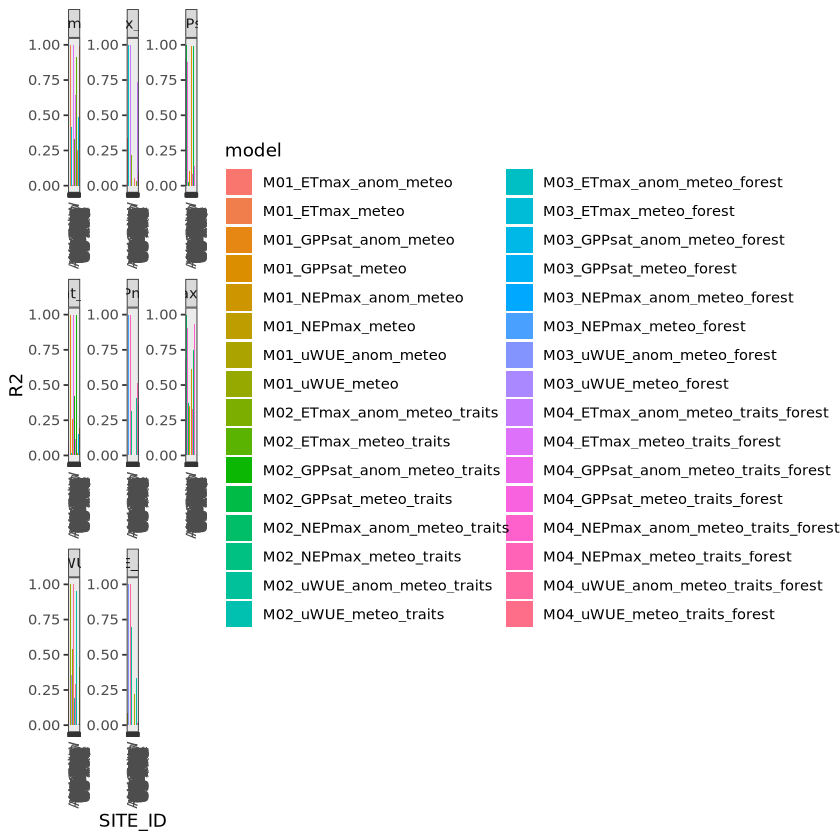

In [4]:
library(ggplot2)

ggplot(site_perf, aes(x = SITE_ID, y = R2, fill = model)) +
  geom_col(position = "dodge") +
  facet_wrap(~response, scales = "free") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90))

In [5]:
library(data.table)
library(ranger)
library(fastshap)

# ---------------------------------------------------------
# Load MASTER dataset
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

# ---------------------------------------------------------
# Define predictors (same as best model)
# ---------------------------------------------------------

lag24_vars   <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
trait_vars   <- readLines("derived_tables/vars_traits_master_3yr.txt")
deadwood_vars <- readLines("derived_tables/vars_deadwood_master_3yr.txt")
anom_vars    <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

predictors <- c(lag24_vars, trait_vars, deadwood_vars, anom_vars)
predictors <- predictors[predictors %in% names(dt)]

# ---------------------------------------------------------
# Prepare data
# ---------------------------------------------------------

model_dt <- dt[, c("uWUE", predictors), with = FALSE]
model_dt <- model_dt[complete.cases(model_dt)]

X <- model_dt[, ..predictors]
y <- model_dt$uWUE

# ---------------------------------------------------------
# Train model
# ---------------------------------------------------------

rf_model <- ranger(
  x = X,
  y = y,
  num.trees = 500,
  importance = "permutation",
  seed = 42
)


Attaching package: ‘fastshap’


The following object is masked from ‘package:dplyr’:

    explain




In [6]:
# prediction wrapper
pred_fun <- function(object, newdata) {
  predict(object, data = newdata)$predictions
}

# compute SHAP
shap_values <- fastshap::explain(
  rf_model,
  X = X,
  pred_wrapper = pred_fun,
  nsim = 50  # increase to 100 for final paper
)

shap_dt <- as.data.table(shap_values)

In [7]:
# create variable groups
group_map <- data.table(variable = names(X))

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      fifelse(variable %in% anom_vars, "Memory",
                      "Other"))))]

In [8]:
# mean absolute SHAP per variable
shap_long <- melt(shap_dt, variable.name = "variable", value.name = "shap")

shap_long <- merge(shap_long, group_map, by = "variable")

group_importance <- shap_long[, .(
  mean_abs_shap = mean(abs(shap), na.rm = TRUE)
), by = group]

# normalize (optional but recommended)
group_importance[, rel_importance := mean_abs_shap / sum(mean_abs_shap)]

Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


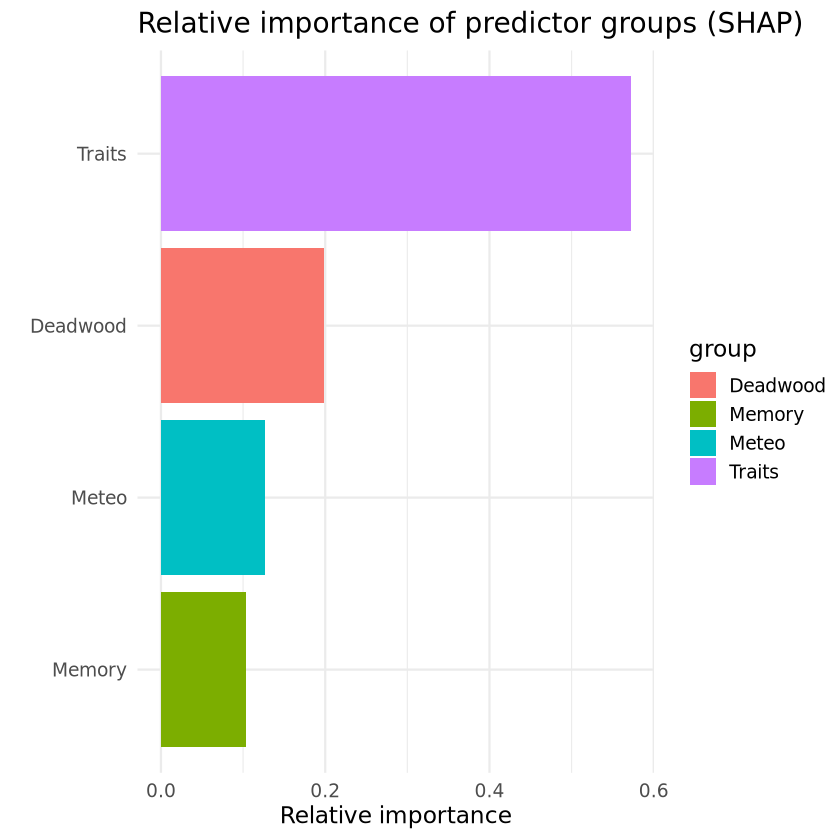

In [9]:
library(ggplot2)

ggplot(group_importance, aes(x = reorder(group, rel_importance), y = rel_importance, fill = group)) +
  geom_col() +
  coord_flip() +
  theme_minimal(base_size = 14) +
  labs(
    title = "Relative importance of predictor groups (SHAP)",
    x = "",
    y = "Relative importance"
  )

In [11]:
library(data.table)

pred <- fread("derived_tables/EFP_batch_predictions_ALL_3yr_lag24_memory.csv")

In [13]:
pred[, model_type := fifelse(grepl("traits_deadwood_memory", model), "full_memory",
                     fifelse(grepl("deadwood_memory", model), "memory",
                     fifelse(grepl("traits_deadwood", model), "full",
                     fifelse(grepl("deadwood", model), "deadwood",
                     fifelse(grepl("traits", model), "traits",
                     "meteo")))))]

In [14]:
rmse_site <- pred[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(SITE_ID, response, model_type)]

In [15]:
rmse_wide <- dcast(
  rmse_site,
  SITE_ID + response ~ model_type,
  value.var = "RMSE"
)

In [16]:
rmse_wide[, delta_traits := traits - meteo]
rmse_wide[, delta_deadwood := deadwood - meteo]
rmse_wide[, delta_full := full - meteo]

rmse_wide[, delta_memory := memory - meteo]
rmse_wide[, delta_full_memory := full_memory - meteo]

In [17]:
names(rmse_wide)

[1] "SITE_ID"           "response"          "deadwood"         
 [4] "full"              "full_memory"       "memory"           
 [7] "meteo"             "traits"            "delta_traits"     
[10] "delta_deadwood"    "delta_full"        "delta_memory"     
[13] "delta_full_memory"

In [18]:
summary(rmse_wide$delta_full_memory)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
-4.898716 -0.129552 -0.000058 -0.050727  0.124724  4.237683 

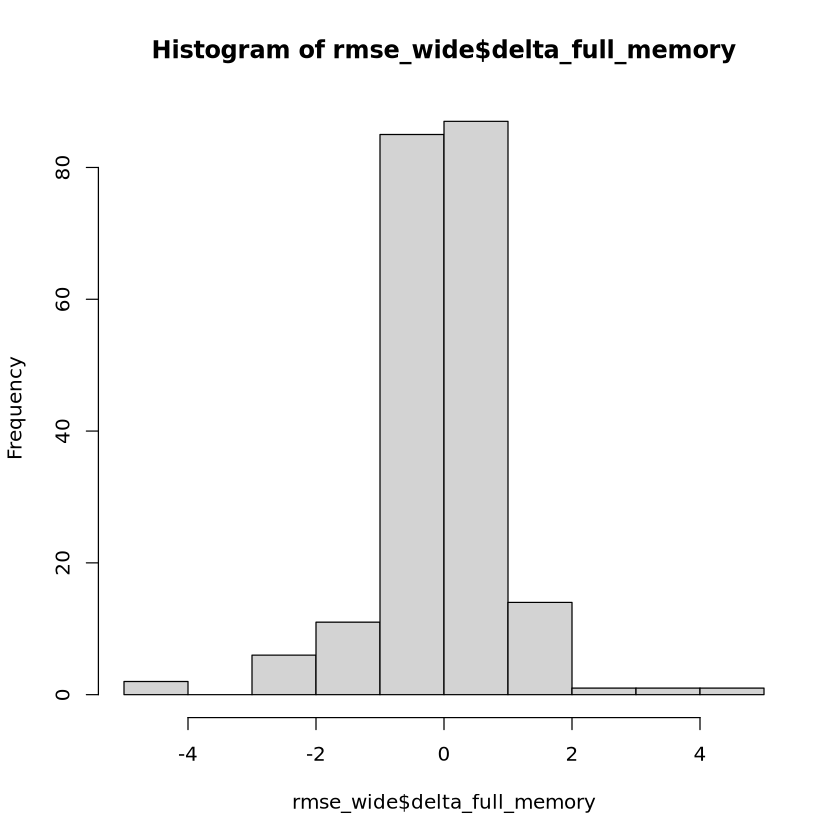

In [19]:
hist(rmse_wide$delta_full_memory)

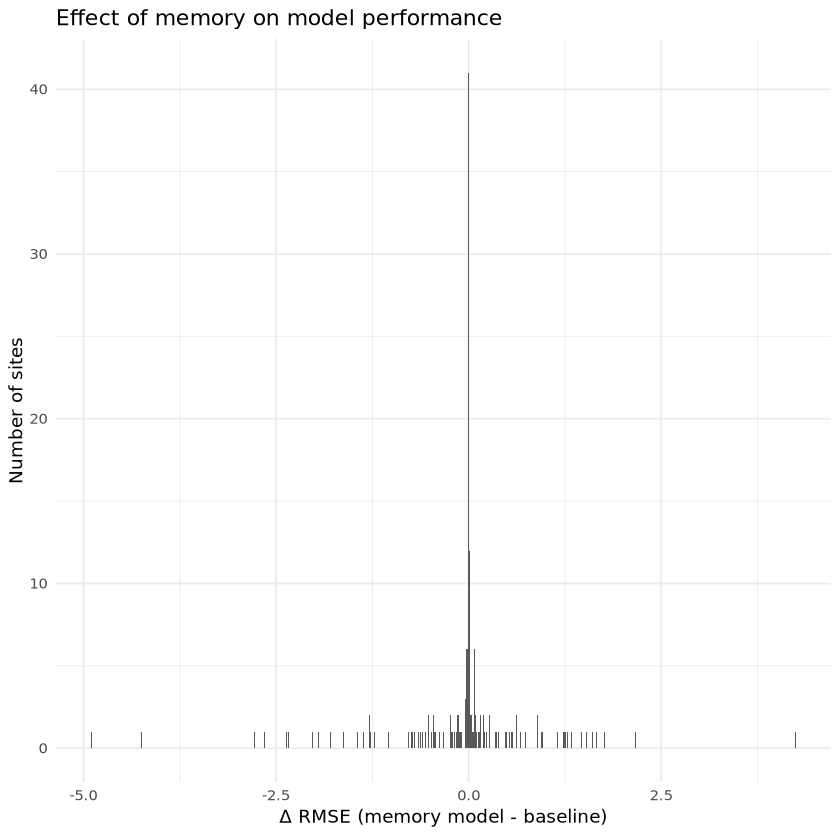

In [22]:
ggplot(rmse_wide, aes(x = delta_full_memory)) +
  geom_histogram(binwidth = 0.01) +
  theme_minimal() +
  labs(
    title = "Effect of memory on model performance",
    x = expression(Delta~RMSE~"(memory model - baseline)"),
    y = "Number of sites"
  )

In [23]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# GROUPED SHAP IMPORTANCE
# overall, by EFP, by IGBP, by EFP x IGBP
# =========================================================

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# if IGBP is not present in the master file, bring it in
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Define response variables
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 3) Define predictor groups
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
memory_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
memory_vars   <- memory_vars[memory_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars, memory_vars))

cat("Predictor group sizes:\n")
cat("Meteo   :", length(lag24_vars), "\n")
cat("Traits  :", length(trait_vars), "\n")
cat("Deadwood:", length(deadwood_vars), "\n")
cat("Memory  :", length(memory_vars), "\n")

# ---------------------------------------------------------
# 4) Variable -> group lookup
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      fifelse(variable %in% memory_vars, "Memory",
                      "Other"))))]

# ---------------------------------------------------------
# 5) Helper: compute grouped SHAP for one response/subset
# ---------------------------------------------------------

compute_grouped_shap <- function(data_subset,
                                 response_var,
                                 id_label,
                                 nsim = 30,
                                 num_trees = 500,
                                 min_rows = 30,
                                 min_sites = 8) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat("Running:", id_label, "| response =", response_var,
      "| rows =", n_rows, "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped (too few rows/sites)\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    importance = "permutation",
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_long <- melt(
    shap_dt,
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  out <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = group]
  
  out[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE)]
  out[, response := response_var]
  out[, subset_id := id_label]
  out[, n_rows := n_rows]
  out[, n_sites := n_sites]
  
  setcolorder(out, c("subset_id", "response", "group", "mean_abs_shap",
                     "rel_importance", "n_rows", "n_sites"))
  
  return(out)
}

# ---------------------------------------------------------
# 6) Overall grouped SHAP for each EFP
# ---------------------------------------------------------

overall_list <- list()

for (resp in response_vars) {
  overall_list[[resp]] <- compute_grouped_shap(
    data_subset = dt,
    response_var = resp,
    id_label = "Overall",
    nsim = 30,
    num_trees = 500,
    min_rows = 30,
    min_sites = 8
  )
}

shap_overall <- rbindlist(overall_list, fill = TRUE)

# ---------------------------------------------------------
# 7) Grouped SHAP by IGBP (response pooled separately)
#    one result per IGBP and EFP
# ---------------------------------------------------------

igbp_levels <- sort(unique(na.omit(dt$IGBP)))
igbp_list <- list()
k <- 1

for (resp in response_vars) {
  for (ig in igbp_levels) {
    d_sub <- dt[IGBP == ig]
    igbp_list[[k]] <- compute_grouped_shap(
      data_subset = d_sub,
      response_var = resp,
      id_label = paste0("IGBP_", ig),
      nsim = 30,
      num_trees = 500,
      min_rows = 20,
      min_sites = 5
    )
    k <- k + 1
  }
}

shap_by_igbp <- rbindlist(igbp_list, fill = TRUE)

# extract plain IGBP label
if (nrow(shap_by_igbp) > 0) {
  shap_by_igbp[, IGBP := sub("^IGBP_", "", subset_id)]
}

# ---------------------------------------------------------
# 8) EFP x IGBP grouped SHAP
#    (same as above but explicit save object for plotting)
# ---------------------------------------------------------

shap_by_efp_igbp <- copy(shap_by_igbp)

# ---------------------------------------------------------
# 9) Save tables
# ---------------------------------------------------------

fwrite(shap_overall, "derived_tables/grouped_shap_overall.csv")
fwrite(shap_by_igbp, "derived_tables/grouped_shap_by_igbp.csv")
fwrite(shap_by_efp_igbp, "derived_tables/grouped_shap_by_efp_igbp.csv")

cat("\nSaved grouped SHAP tables:\n")
cat("- derived_tables/grouped_shap_overall.csv\n")
cat("- derived_tables/grouped_shap_by_igbp.csv\n")
cat("- derived_tables/grouped_shap_by_efp_igbp.csv\n")

# ---------------------------------------------------------
# 10) Plots
# ---------------------------------------------------------

# ---- Plot A: overall for each EFP
p1 <- ggplot(shap_overall, aes(x = group, y = rel_importance, fill = group))
p1 <- p1 + geom_col()
p1 <- p1 + facet_wrap(~response, scales = "free_y")
p1 <- p1 + coord_flip()
p1 <- p1 + labs(
  title = "Relative importance of predictor groups (SHAP) by EFP",
  x = "",
  y = "Relative importance"
)
p1 <- p1 + theme_minimal(base_size = 14)

ggsave("derived_tables/plot_grouped_shap_by_efp.png", p1, width = 10, height = 7, dpi = 300)

# ---- Plot B: pooled by IGBP across EFP? no, use one EFP per facet x IGBP
# if too many panels, save large figure
if (nrow(shap_by_efp_igbp) > 0) {
  p2 <- ggplot(shap_by_efp_igbp, aes(x = group, y = rel_importance, fill = group))
  p2 <- p2 + geom_col()
  p2 <- p2 + facet_wrap(~IGBP, scales = "free_y")
  p2 <- p2 + coord_flip()
  p2 <- p2 + labs(
    title = "Relative importance of predictor groups (SHAP) by IGBP",
    x = "",
    y = "Relative importance"
  )
  p2 <- p2 + theme_minimal(base_size = 12)
  
  ggsave("derived_tables/plot_grouped_shap_by_igbp.png", p2, width = 12, height = 9, dpi = 300)
  
  # ---- Plot C: EFP x IGBP
  p3 <- ggplot(shap_by_efp_igbp, aes(x = group, y = rel_importance, fill = group))
  p3 <- p3 + geom_col()
  p3 <- p3 + facet_grid(response ~ IGBP, scales = "free_y")
  p3 <- p3 + coord_flip()
  p3 <- p3 + labs(
    title = "Relative importance of predictor groups (SHAP) by EFP and IGBP",
    x = "",
    y = "Relative importance"
  )
  p3 <- p3 + theme_minimal(base_size = 11)
  
  ggsave("derived_tables/plot_grouped_shap_by_efp_igbp.png", p3, width = 16, height = 10, dpi = 300)
}

cat("\nSaved grouped SHAP plots:\n")
cat("- derived_tables/plot_grouped_shap_by_efp.png\n")
cat("- derived_tables/plot_grouped_shap_by_igbp.png\n")
cat("- derived_tables/plot_grouped_shap_by_efp_igbp.png\n")

Loaded dataset: 156 rows x 335 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo   : 288 
Traits  : 21 
Deadwood: 8 
Memory  : 8 
Running: Overall | response = uWUE | rows = 156 | sites = 52 


Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


Running: Overall | response = ETmax | rows = 156 | sites = 52 


Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


Running: Overall | response = GPPsat | rows = 156 | sites = 52 


...

Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


Running: IGBP_DNF | response = GPPsat | rows = 4 | sites = 1 
 -> skipped (too few rows/sites)
Running: IGBP_EBF | response = GPPsat | rows = 13 | sites = 5 
 -> skipped (too few rows/sites)
Running: IGBP_ENF | response = GPPsat | rows = 38 | sites = 12 


Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


Running: IGBP_MF | response = GPPsat | rows = 6 | sites = 1 
 -> skipped (too few rows/sites)
Running: IGBP_OSH | response = GPPsat | rows = 18 | sites = 4 
 -> skipped (too few rows/sites)
Running: IGBP_SAV | response = GPPsat | rows = 5 | sites = 1 
 -> skipped (too few rows/sites)
Running: IGBP_WET | response = GPPsat | rows = 29 | sites = 13 


Warning message in melt.data.table(shap_dt, variable.name = "variable", value.name = "shap"):
“id.vars and measure.vars are internally guessed when both are 'NULL'. All non-numeric/integer/logical type columns are considered id.vars, which in this case are columns []. Consider providing at least one of 'id' or 'measure' vars in future.”


In [24]:
ls()

[1] "all_predictors"       "anom_vars"            "compute_grouped_shap"
 [4] "d_sub"                "deadwood_vars"        "df_predictions"      
 [7] "dt"                   "group_importance"     "group_map"           
[10] "ig"                   "igbp_levels"          "igbp_list"           
[13] "k"                    "lag24_vars"           "memory_vars"         
[16] "meta_dt"              "model_dt"             "overall_list"        
[19] "pred"                 "pred_fun"             "predictors"          
[22] "resp"                 "response_vars"        "rf_model"            
[25] "rmse_site"            "rmse_wide"            "shap_dt"             
[28] "shap_long"            "shap_overall"         "shap_values"         
[31] "site_perf"            "trait_vars"           "userlib"             
[34] "X"                    "y"

In [25]:
library(data.table)

dir.create("derived_tables/checkpoints", showWarnings = FALSE, recursive = TRUE)

if (exists("shap_overall")) {
  fwrite(shap_overall, "derived_tables/checkpoints/shap_overall_partial.csv")
}

if (exists("group_importance")) {
  fwrite(group_importance, "derived_tables/checkpoints/group_importance_partial.csv")
}

if (exists("shap_long")) {
  fwrite(shap_long, "derived_tables/checkpoints/shap_long_partial.csv")
}

if (exists("rmse_site")) {
  fwrite(rmse_site, "derived_tables/checkpoints/rmse_site_partial.csv")
}

if (exists("rmse_wide")) {
  fwrite(rmse_wide, "derived_tables/checkpoints/rmse_wide_partial.csv")
}

if (exists("df_predictions")) {
  fwrite(as.data.table(df_predictions), "derived_tables/checkpoints/df_predictions_partial.csv")
}

if (exists("site_perf")) {
  fwrite(as.data.table(site_perf), "derived_tables/checkpoints/site_perf_partial.csv")
}

save.image("derived_tables/checkpoints/workspace_partial.RData")

cat("Partial results saved.\n")

Partial results saved.


In [1]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# RESUME SHAP: continue only missing IGBP x response runs
# =========================================================

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Define variables
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
memory_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
memory_vars   <- memory_vars[memory_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars, memory_vars))

cat("Predictor group sizes:\n")
cat("Meteo   :", length(lag24_vars), "\n")
cat("Traits  :", length(trait_vars), "\n")
cat("Deadwood:", length(deadwood_vars), "\n")
cat("Memory  :", length(memory_vars), "\n")

# ---------------------------------------------------------
# 3) Variable -> group lookup
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      fifelse(variable %in% memory_vars, "Memory",
                      "Other"))))]

# ---------------------------------------------------------
# 4) Helper
# ---------------------------------------------------------

compute_grouped_shap <- function(data_subset,
                                 response_var,
                                 id_label,
                                 nsim = 10,
                                 num_trees = 500,
                                 min_rows = 30,
                                 min_sites = 8) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat(format(Sys.time(), "%H:%M:%S"),
      "| Running:", id_label,
      "| response =", response_var,
      "| rows =", n_rows,
      "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped (too few rows/sites)\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    importance = "permutation",
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_long <- melt(
    shap_dt,
    measure.vars = names(shap_dt),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  out <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = group]
  
  out[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE)]
  out[, response := response_var]
  out[, subset_id := id_label]
  out[, n_rows := n_rows]
  out[, n_sites := n_sites]
  
  setcolorder(out, c("subset_id", "response", "group", "mean_abs_shap",
                     "rel_importance", "n_rows", "n_sites"))
  
  return(out)
}

# ---------------------------------------------------------
# 5) Save overall SHAP if you already have it in memory
#    otherwise recompute only if needed
# ---------------------------------------------------------

if (!exists("shap_overall")) {
  overall_list <- list()
  for (resp in response_vars) {
    overall_list[[resp]] <- compute_grouped_shap(
      data_subset = dt,
      response_var = resp,
      id_label = "Overall",
      nsim = 10,
      num_trees = 500,
      min_rows = 30,
      min_sites = 8
    )
  }
  shap_overall <- rbindlist(overall_list, fill = TRUE)
}

fwrite(shap_overall, "derived_tables/grouped_shap_overall.csv")

# ---------------------------------------------------------
# 6) Resume IGBP x response runs with checkpoints
# ---------------------------------------------------------

dir.create("derived_tables/shap_checkpoints", showWarnings = FALSE, recursive = TRUE)

igbp_levels <- sort(unique(na.omit(dt$IGBP)))

for (resp in response_vars) {
  for (ig in igbp_levels) {
    
    out_file <- file.path(
      "derived_tables/shap_checkpoints",
      paste0("shap_", resp, "_", ig, ".csv")
    )
    
    if (file.exists(out_file)) {
      cat("Skipping existing file:", out_file, "\n")
      next
    }
    
    d_sub <- dt[IGBP == ig]
    
    res <- tryCatch(
      compute_grouped_shap(
        data_subset = d_sub,
        response_var = resp,
        id_label = paste0("IGBP_", ig),
        nsim = 10,
        num_trees = 500,
        min_rows = 20,
        min_sites = 5
      ),
      error = function(e) {
        cat("ERROR for", resp, ig, ":", conditionMessage(e), "\n")
        return(NULL)
      }
    )
    
    if (!is.null(res) && nrow(res) > 0) {
      fwrite(res, out_file)
      cat("Saved:", out_file, "\n")
    }
  }
}

# ---------------------------------------------------------
# 7) Rebuild combined tables from checkpoint files
# ---------------------------------------------------------

chk_files <- list.files(
  "derived_tables/shap_checkpoints",
  pattern = "^shap_.*\\.csv$",
  full.names = TRUE
)

if (length(chk_files) > 0) {
  shap_by_igbp <- rbindlist(lapply(chk_files, fread), fill = TRUE)
} else {
  shap_by_igbp <- data.table()
}

if (nrow(shap_by_igbp) > 0) {
  shap_by_igbp[, IGBP := sub("^IGBP_", "", subset_id)]
}

shap_by_efp_igbp <- copy(shap_by_igbp)

# ---------------------------------------------------------
# 8) Save combined tables
# ---------------------------------------------------------

fwrite(shap_by_igbp, "derived_tables/grouped_shap_by_igbp.csv")
fwrite(shap_by_efp_igbp, "derived_tables/grouped_shap_by_efp_igbp.csv")

cat("\nSaved grouped SHAP tables:\n")
cat("- derived_tables/grouped_shap_overall.csv\n")
cat("- derived_tables/grouped_shap_by_igbp.csv\n")
cat("- derived_tables/grouped_shap_by_efp_igbp.csv\n")

# ---------------------------------------------------------
# 9) Plots
# ---------------------------------------------------------

# Plot A: by EFP overall
p1 <- ggplot(shap_overall, aes(x = group, y = rel_importance, fill = group)) +
  geom_col() +
  facet_wrap(~response, scales = "free_y") +
  coord_flip() +
  labs(
    title = "Relative importance of predictor groups (SHAP) by EFP",
    x = "",
    y = "Relative importance"
  ) +
  theme_minimal(base_size = 14)

ggsave("derived_tables/plot_grouped_shap_by_efp.png", p1, width = 10, height = 7, dpi = 300)

# Plot B: by IGBP
if (nrow(shap_by_igbp) > 0) {
  p2 <- ggplot(shap_by_igbp, aes(x = group, y = rel_importance, fill = group)) +
    geom_col() +
    facet_wrap(~IGBP, scales = "free_y") +
    coord_flip() +
    labs(
      title = "Relative importance of predictor groups (SHAP) by IGBP",
      x = "",
      y = "Relative importance"
    ) +
    theme_minimal(base_size = 12)
  
  ggsave("derived_tables/plot_grouped_shap_by_igbp.png", p2, width = 12, height = 9, dpi = 300)
  
  # Plot C: by EFP x IGBP
  p3 <- ggplot(shap_by_efp_igbp, aes(x = group, y = rel_importance, fill = group)) +
    geom_col() +
    facet_grid(response ~ IGBP, scales = "free_y") +
    coord_flip() +
    labs(
      title = "Relative importance of predictor groups (SHAP) by EFP and IGBP",
      x = "",
      y = "Relative importance"
    ) +
    theme_minimal(base_size = 11)
  
  ggsave("derived_tables/plot_grouped_shap_by_efp_igbp.png", p3, width = 16, height = 10, dpi = 300)
}

cat("\nSaved grouped SHAP plots:\n")
cat("- derived_tables/plot_grouped_shap_by_efp.png\n")
cat("- derived_tables/plot_grouped_shap_by_igbp.png\n")
cat("- derived_tables/plot_grouped_shap_by_efp_igbp.png\n")

Loaded dataset: 156 rows x 335 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo   : 288 
Traits  : 21 
Deadwood: 8 
Memory  : 8 
12:01:53 | Running: Overall | response = uWUE | rows = 156 | sites = 52 
12:06:35 | Running: Overall | response = ETmax | rows = 156 | sites = 52 
12:11:17 | Running: Overall | response = GPPsat | rows = 156 | sites = 52 
12:15:57 | Running: Overall | response = NEPmax | rows = 156 | sites = 52 
12:20:57 | Running: IGBP_CVM | response = uWUE | rows = 4 | sites = 2 
 -> skipped (too few rows/sites)
12:20:57 | Running: IGBP_DBF | response = uWUE | rows = 39 | sites = 13 
Saved: derived_tables/shap_checkpoints/shap_uWUE_DBF.csv 
12:24:54 | Running: IGBP_DNF | response = uWUE | rows = 4 | sites = 1 
 -> skipped (too few rows/sites)
12:24:55 | Running: IGBP_EBF | response = uWUE | rows = 13 | sites = 5 
 -> skipped (too few rows/sites)
12:24:55 | Running: IGBP_ENF | response = uWUE | rows = 38 | sites = 12 
Saved: derived_tables/shap_chec

In [8]:
library(data.table)
library(ggplot2)

# =========================================================
# DELTA RMSE PLOTS: mortality effect
# compare M04 (meteo + traits + forest) vs M02 (meteo + traits)
# positive delta_RMSE = improvement from adding mortality
# =========================================================

# ---------------------------------------------------------
# 1) Load predictions
# ---------------------------------------------------------

pred <- fread("derived_tables/EFP_batch_predictions_ALL_3yr.csv")

# If needed, bring IGBP from metadata
meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 2) Keep only the four raw EFPs
# ---------------------------------------------------------

efp_keep <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
pred <- pred[response %in% efp_keep]

# ---------------------------------------------------------
# 3) Keep only models M02 and M04
#    M02 = meteo + traits
#    M04 = meteo + traits + forest
# ---------------------------------------------------------

pred <- pred[
  grepl("^M02_", model) | grepl("^M04_", model)
]

# label model group
pred[, model_group := fifelse(grepl("^M02_", model), "M02_traits",
                       fifelse(grepl("^M04_", model), "M04_traits_forest", NA_character_))]

pred <- pred[!is.na(model_group)]

# ---------------------------------------------------------
# 4) Compute RMSE per site x response x model
# ---------------------------------------------------------

rmse_site <- pred[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(SITE_ID, response, model_group)]

# ---------------------------------------------------------
# 5) Reshape wide and compute delta RMSE
#    positive = improvement from adding forest
# ---------------------------------------------------------

rmse_wide <- dcast(
  rmse_site,
  SITE_ID + response ~ model_group,
  value.var = "RMSE"
)

rmse_wide[, delta_RMSE := M02_traits - M04_traits_forest]

# add IGBP
rmse_wide <- merge(rmse_wide, meta_dt, by = "SITE_ID", all.x = TRUE)

# save
fwrite(rmse_wide, "derived_tables/deltaRMSE_M04_vs_M02_per_site.csv")

# ---------------------------------------------------------

# 6) Reorder SITE_ID within each response for plotting

#    IMPORTANT: make facet-specific labels

# ---------------------------------------------------------

plot_site <- copy(rmse_wide)

# create unique label per response-site combination

plot_site[, SITE_ID_facet := paste(response, SITE_ID, sep = "___")]

# order within each response from good to bad

plot_site <- plot_site[order(response, delta_RMSE)]

plot_site[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# ---------------------------------------------------------

# 7) Site-level bar plot

# ---------------------------------------------------------

p_site <- ggplot(plot_site, aes(x = delta_RMSE, y = SITE_ID_facet, fill = IGBP)) +

  geom_col(color = "black", linewidth = 0.1) +

  facet_wrap(~response, scales = "free", ncol = 2) +

  geom_vline(xintercept = 0, linetype = "dashed") +

  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +

  labs(

    title = "Effect of tree mortality on model performance",

    x = expression(Delta*RMSE~"(M02 - M04)"),

    y = "Site"

  ) +

  theme_bw(base_size = 11) +

  theme(

    strip.background = element_rect(fill = "grey90"),

    panel.grid.major.y = element_line(colour = "grey90"),

    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 5)

  )

ggsave(

  "derived_tables/plot_deltaRMSE_per_site_M04_vs_M02.png",

  p_site, width = 10, height = 12, dpi = 300

)

# ---------------------------------------------------------
# 8) IGBP-level boxplot
# ---------------------------------------------------------

p_igbp <- ggplot(rmse_wide, aes(x = IGBP, y = delta_RMSE, fill = IGBP)) +
  geom_boxplot(outlier.shape = 16, outlier.size = 1.8) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Effect of mortality across ecosystem types",
    x = "Ecosystem type",
    y = expression(Delta*RMSE~"(M02 - M04)")
  ) +
  theme_bw(base_size = 11) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.major = element_line(colour = "grey90"),
    panel.grid.minor = element_blank()
  )

ggsave(
  "derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png",
  p_igbp, width = 10, height = 8, dpi = 300
)

# ---------------------------------------------------------
# 9) Print summaries
# ---------------------------------------------------------

cat("\nDelta RMSE summary by response:\n")
print(
  rmse_wide[, .(
    mean_delta_RMSE = mean(delta_RMSE, na.rm = TRUE),
    median_delta_RMSE = median(delta_RMSE, na.rm = TRUE),
    n_sites = uniqueN(SITE_ID)
  ), by = response]
)

cat("\nFiles written:\n")
cat("- derived_tables/deltaRMSE_M04_vs_M02_per_site.csv\n")
cat("- derived_tables/plot_deltaRMSE_per_site_M04_vs_M02.png\n")
cat("- derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png\n")


Delta RMSE summary by response:
   response mean_delta_RMSE median_delta_RMSE n_sites
     <char>           <num>             <num>   <int>
1:    ETmax   -0.0002446592     -0.0001046781      64
2:   GPPsat   -0.0070578118     -0.0049362581      64
3:   NEPmax   -0.0141133931     -0.0365675209      64
4:     uWUE    0.0068911886      0.0039609821      64

Files written:
- derived_tables/deltaRMSE_M04_vs_M02_per_site.csv
- derived_tables/plot_deltaRMSE_per_site_M04_vs_M02.png
- derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png


In [5]:
library(data.table)
library(ggplot2)

# =========================================================
# DELTA RMSE PLOTS: deadwood effect
# (1) without memory: M02 vs M04
# (2) with memory   : M07 vs M06
# positive delta_RMSE = improvement from adding deadwood
# =========================================================

# ---------------------------------------------------------
# 0) Output folders
# ---------------------------------------------------------

out_dir_base <- "derived_tables/final_results_3yr"
out_dir_nomem <- file.path(out_dir_base, "deltaRMSE_no_memory")
out_dir_mem   <- file.path(out_dir_base, "deltaRMSE_with_memory")

dir.create(out_dir_nomem, recursive = TRUE, showWarnings = FALSE)
dir.create(out_dir_mem,   recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load predictions
# ---------------------------------------------------------

pred <- fread(file.path(out_dir_base, "EFP_batch_predictions_ALL_3yr_lag24_memory_final.csv"))

# metadata
meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 2) Keep only raw EFPs
# ---------------------------------------------------------

efp_keep <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
pred <- pred[response %in% efp_keep]

# ---------------------------------------------------------
# 3) Helper function for one delta-RMSE comparison
# ---------------------------------------------------------

make_delta_rmse_outputs <- function(pred_dt,
                                    meta_dt,
                                    model_a_regex,
                                    model_b_regex,
                                    model_a_label,
                                    model_b_label,
                                    comparison_label,
                                    out_dir) {
  
  cat("\n====================================\n")
  cat("Running comparison:", comparison_label, "\n")
  cat("Model A:", model_a_label, "\n")
  cat("Model B:", model_b_label, "\n")
  cat("Delta RMSE =", model_a_label, "-", model_b_label, "\n")
  cat("====================================\n")
  
  # -----------------------------------
  # Filter models
  # -----------------------------------
  
  this_pred <- pred_dt[
    grepl(model_a_regex, model) | grepl(model_b_regex, model)
  ]
  
  this_pred[, model_group := fifelse(
    grepl(model_a_regex, model), model_a_label,
    fifelse(grepl(model_b_regex, model), model_b_label, NA_character_)
  )]
  
  this_pred <- this_pred[!is.na(model_group)]
  
  # -----------------------------------
  # RMSE per site x response x model
  # -----------------------------------
  
  rmse_site <- this_pred[, .(
    RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
  ), by = .(SITE_ID, response, model_group)]
  
  # -----------------------------------
  # Wide table + delta
  # positive = model_b improves over model_a
  # -----------------------------------
  
  rmse_wide <- dcast(
    rmse_site,
    SITE_ID + response ~ model_group,
    value.var = "RMSE"
  )
  
  rmse_wide[, delta_RMSE := get(model_a_label) - get(model_b_label)]
  
  # add IGBP
  rmse_wide <- merge(rmse_wide, meta_dt, by = "SITE_ID", all.x = TRUE)
  
  # save table
  fwrite(
    rmse_wide,
    file.path(out_dir, paste0("deltaRMSE_", comparison_label, "_per_site.csv"))
  )
  
  # -----------------------------------
  # Reorder SITE_ID within each response
  # -----------------------------------
  
  plot_site <- copy(rmse_wide)
  
  plot_site[, SITE_ID_facet := paste(response, SITE_ID, sep = "___")]
  plot_site <- plot_site[order(response, delta_RMSE)]
  plot_site[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]
  
  # -----------------------------------
  # Site-level bar plot
  # -----------------------------------
  
  p_site <- ggplot(plot_site, aes(x = delta_RMSE, y = SITE_ID_facet, fill = IGBP)) +
    geom_col(color = "black", linewidth = 0.1) +
    facet_wrap(~response, scales = "free", ncol = 2) +
    geom_vline(xintercept = 0, linetype = "dashed") +
    scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
    labs(
      title = paste("Effect of deadwood on model performance -", comparison_label),
      x = bquote(Delta * RMSE ~ "(" * .(model_a_label) * " - " * .(model_b_label) * ")"),
      y = "Site"
    ) +
    theme_bw(base_size = 11) +
    theme(
      strip.background = element_rect(fill = "grey90"),
      panel.grid.major.y = element_line(colour = "grey90"),
      panel.grid.minor = element_blank(),
      axis.text.y = element_text(size = 5)
    )
  
  ggsave(
    file.path(out_dir, paste0("plot_deltaRMSE_per_site_", comparison_label, ".png")),
    p_site, width = 10, height = 12, dpi = 300
  )
  
  # -----------------------------------
  # IGBP-level boxplot
  # -----------------------------------
  
  p_igbp <- ggplot(rmse_wide, aes(x = IGBP, y = delta_RMSE, fill = IGBP)) +
    geom_boxplot(outlier.shape = 16, outlier.size = 1.8) +
    facet_wrap(~response, scales = "free", ncol = 2) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    labs(
      title = paste("Effect of deadwood across ecosystem types -", comparison_label),
      x = "Ecosystem type",
      y = bquote(Delta * RMSE ~ "(" * .(model_a_label) * " - " * .(model_b_label) * ")")
    ) +
    theme_bw(base_size = 11) +
    theme(
      strip.background = element_rect(fill = "grey90"),
      panel.grid.major = element_line(colour = "grey90"),
      panel.grid.minor = element_blank()
    )
  
  ggsave(
    file.path(out_dir, paste0("plot_deltaRMSE_by_IGBP_", comparison_label, ".png")),
    p_igbp, width = 10, height = 8, dpi = 300
  )
  
  # -----------------------------------
  # Summary
  # -----------------------------------
  
  summary_dt <- rmse_wide[, .(
    mean_delta_RMSE = mean(delta_RMSE, na.rm = TRUE),
    median_delta_RMSE = median(delta_RMSE, na.rm = TRUE),
    n_sites = uniqueN(SITE_ID)
  ), by = response]
  
  fwrite(
    summary_dt,
    file.path(out_dir, paste0("deltaRMSE_summary_", comparison_label, ".csv"))
  )
  
  cat("\nDelta RMSE summary:\n")
  print(summary_dt)
  
  cat("\nFiles written to", out_dir, ":\n")
  cat("-", file.path(out_dir, paste0("deltaRMSE_", comparison_label, "_per_site.csv")), "\n")
  cat("-", file.path(out_dir, paste0("plot_deltaRMSE_per_site_", comparison_label, ".png")), "\n")
  cat("-", file.path(out_dir, paste0("plot_deltaRMSE_by_IGBP_", comparison_label, ".png")), "\n")
  cat("-", file.path(out_dir, paste0("deltaRMSE_summary_", comparison_label, ".csv")), "\n")
}

# ---------------------------------------------------------
# 4) NO MEMORY comparison
#    Deadwood effect without memory:
#    M02 (meteo+traits) vs M04 (meteo+traits+deadwood)
# ---------------------------------------------------------

make_delta_rmse_outputs(
  pred_dt = pred,
  meta_dt = meta_dt,
  model_a_regex = "^M02_",
  model_b_regex = "^M04_",
  model_a_label = "M02_traits",
  model_b_label = "M04_traits_deadwood",
  comparison_label = "no_memory_M02_vs_M04",
  out_dir = out_dir_nomem
)

# ---------------------------------------------------------
# 5) WITH MEMORY comparison
#    Deadwood effect after memory:
#    M07 (meteo+traits+memory) vs M06 (meteo+traits+deadwood+memory)
# ---------------------------------------------------------

make_delta_rmse_outputs(
  pred_dt = pred,
  meta_dt = meta_dt,
  model_a_regex = "^M07_",
  model_b_regex = "^M06_",
  model_a_label = "M07_traits_memory",
  model_b_label = "M06_traits_deadwood_memory",
  comparison_label = "with_memory_M07_vs_M06",
  out_dir = out_dir_mem
)

cat("\n====================================\n")
cat("ALL DELTA-RMSE OUTPUTS COMPLETED\n")
cat("====================================\n")


Running comparison: no_memory_M02_vs_M04 
Model A: M02_traits 
Model B: M04_traits_deadwood 
Delta RMSE = M02_traits - M04_traits_deadwood 

Delta RMSE summary:
   response mean_delta_RMSE median_delta_RMSE n_sites
     <char>           <num>             <num>   <int>
1:    ETmax    -0.000772867     -0.0004651072      52
2:   GPPsat     0.064148532     -0.0391538341      52
3:   NEPmax     0.152158360      0.1025852033      52
4:     uWUE     0.004396065      0.0036694757      52

Files written to derived_tables/final_results_3yr/deltaRMSE_no_memory :
- derived_tables/final_results_3yr/deltaRMSE_no_memory/deltaRMSE_no_memory_M02_vs_M04_per_site.csv 
- derived_tables/final_results_3yr/deltaRMSE_no_memory/plot_deltaRMSE_per_site_no_memory_M02_vs_M04.png 
- derived_tables/final_results_3yr/deltaRMSE_no_memory/plot_deltaRMSE_by_IGBP_no_memory_M02_vs_M04.png 
- derived_tables/final_results_3yr/deltaRMSE_no_memory/deltaRMSE_summary_no_memory_M02_vs_M04.csv 

Running comparison: with_memory_

In [1]:
###best models RMSE
library(data.table)
library(ggplot2)

# =========================================================
# SITE-SPECIFIC RMSE FOR THE BEST MODEL OF EACH EFP
# star = top 30 disturbed sites
# =========================================================

# ---------------------------------------------------------
# 1) Load predictions from final model run
# ---------------------------------------------------------

pred <- fread("derived_tables/final_results_3yr/EFP_batch_predictions_ALL_3yr_lag24_memory_final.csv")

# ---------------------------------------------------------
# 2) Define best model per EFP from your summary table
# ---------------------------------------------------------

best_models <- data.table(
  response = c("ETmax", "GPPsat", "NEPmax", "uWUE"),
  model = c(
    "M03_ETmax_meteo24_deadwood_3yr",
    "M04_GPPsat_meteo24_traits_deadwood_3yr",
    "M04_NEPmax_meteo24_traits_deadwood_3yr",
    "M06_uWUE_meteo24_traits_deadwood_memory_3yr"
  )
)

# keep only best models
pred_best <- merge(pred, best_models, by = c("response", "model"))

# ---------------------------------------------------------
# 3) Load metadata
# ---------------------------------------------------------

meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 4) Define top 30 disturbed sites
#    based on mean annual disturbance intensity
# ---------------------------------------------------------

dist_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

site_dist <- dist_dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  )
), by = SITE_ID]

site_dist <- site_dist[!is.na(disturbance_pct)]
top30_sites <- site_dist[order(-disturbance_pct)][1:30, SITE_ID]

# ---------------------------------------------------------
# 5) Compute site-specific RMSE for best model
# ---------------------------------------------------------

rmse_site <- pred_best[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(response, model, SITE_ID)]

rmse_site <- merge(rmse_site, meta_dt, by = "SITE_ID", all.x = TRUE)

# add star labels
rmse_site[, SITE_ID_star := ifelse(
  SITE_ID %in% top30_sites,
  paste0(SITE_ID, " ★"),
  SITE_ID
)]

# ---------------------------------------------------------
# 6) Facet-specific ordering
#    order from low RMSE to high RMSE within each EFP
# ---------------------------------------------------------

plot_dt <- copy(rmse_site)

plot_dt <- plot_dt[order(response, RMSE)]
plot_dt[, SITE_ID_facet := paste(response, SITE_ID_star, sep = "___")]
plot_dt[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# ---------------------------------------------------------
# 7) Plot
# ---------------------------------------------------------

p <- ggplot(plot_dt, aes(x = RMSE, y = SITE_ID_facet, fill = IGBP)) +
  geom_col(color = "black", linewidth = 0.1) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  labs(
    title = "Site-specific RMSE for the best-performing model of each EFP",
    subtitle = "Sites marked with ★ are among the top 30 most disturbed sites",
    x = "Site-specific RMSE",
    y = "Site"
  ) +
  theme_bw(base_size = 11) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.major.y = element_line(colour = "grey90"),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 5)
  )

ggsave(
  "derived_tables/final_results_3yr/plot_best_model_site_RMSE_starred.png",
  p,
  width = 10,
  height = 12,
  dpi = 300
)

# ---------------------------------------------------------
# 8) Save table
# ---------------------------------------------------------

fwrite(
  rmse_site,
  "derived_tables/final_results_3yr/best_model_site_RMSE_starred.csv"
)

cat("Files written:\n")
cat("- derived_tables/final_results_3yr/plot_best_model_site_RMSE_starred.png\n")
cat("- derived_tables/final_results_3yr/best_model_site_RMSE_starred.csv\n")

Files written:
- derived_tables/final_results_3yr/plot_best_model_site_RMSE_starred.png
- derived_tables/final_results_3yr/best_model_site_RMSE_starred.csv


In [2]:
# keep top + bottom sites per EFP
plot_dt <- copy(rmse_site)

plot_dt <- plot_dt[
  ,
  .SD[order(RMSE)][c(1:15, (.N-14):.N)],
  by = response
]

# reorder properly
plot_dt <- plot_dt[order(response, RMSE)]

plot_dt[, SITE_ID_facet := paste(response, SITE_ID_star, sep = "___")]
plot_dt[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# plot
p <- ggplot(plot_dt, aes(x = RMSE, y = SITE_ID_facet, fill = IGBP)) +
  geom_col(color = "black", linewidth = 0.1) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  labs(
    title = "Best model performance: best vs worst sites",
    subtitle = "Top and bottom 15 sites per EFP; ★ = high disturbance",
    x = "Site-specific RMSE",
    y = "Site"
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.y = element_text(size = 7)
  )

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'AU-Whr ★' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'AU-Whr ★' in 'mbcsToSbcs': dot substituted for <98>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'AU-Whr ★' in 'mbcsToSbcs': dot substituted for <85>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'DE-Hte ★' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'DE-Hte ★' in 'mbcsToSbcs': dot substituted for <98>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'DE-Hte ★' in 'mbcsToSbcs': dot substituted for <85>”
Warning message in grid.Call(C_textBounds, as.

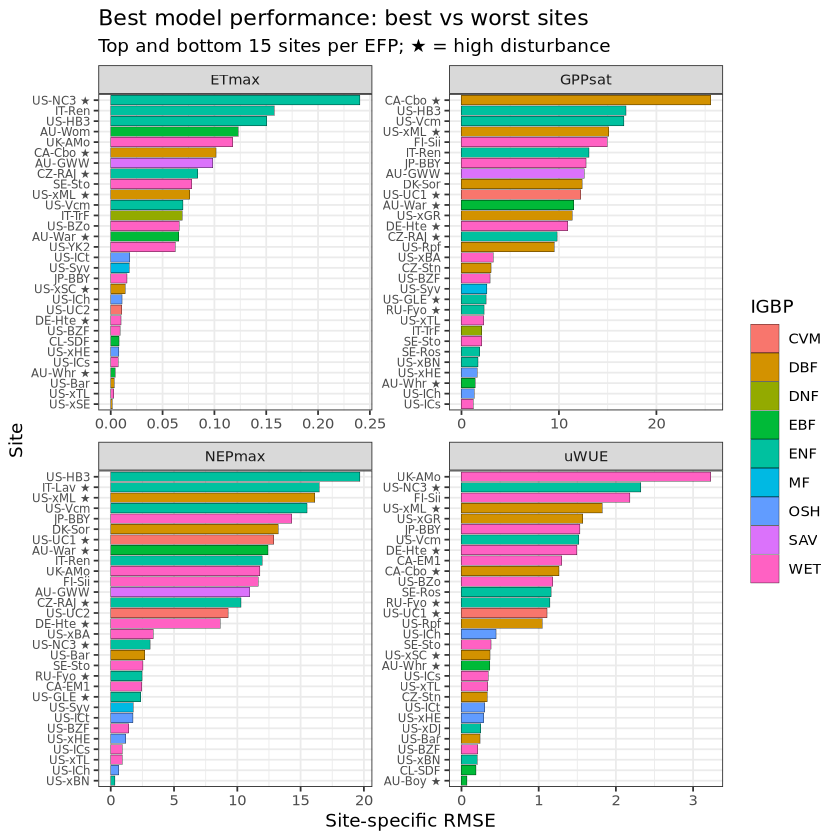

In [3]:
print(p)

In [4]:
ggsave(
  "derived_tables/final_results_3yr/plot_top15_model_site_RMSE_starred.png",
  p,
  width = 10,
  height = 12,
  dpi = 300
)

In [1]:
library(data.table)
library(ggplot2)

# =========================================================
# KILLER FIGURE:
# Disturbance intensity vs benefit of adding deadwood
# rows = EFP
# cols = no memory / with memory
# =========================================================

# ---------------------------------------------------------
# 1) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/killer_figure"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 2) Load delta RMSE tables
# ---------------------------------------------------------

dt_nomem <- fread(
  "derived_tables/final_results_3yr/deltaRMSE_no_memory/deltaRMSE_no_memory_M02_vs_M04_per_site.csv"
)

dt_mem <- fread(
  "derived_tables/final_results_3yr/deltaRMSE_with_memory/deltaRMSE_with_memory_M07_vs_M06_per_site.csv"
)

dt_nomem[, context := "Without memory"]
dt_mem[, context := "With memory"]

delta_dt <- rbindlist(list(dt_nomem, dt_mem), fill = TRUE)

# ---------------------------------------------------------
# 3) Load disturbance metric
#    mean annual disturbance intensity in percentage points
# ---------------------------------------------------------

dist_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

site_dist <- dist_dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  )
), by = SITE_ID]

site_dist <- site_dist[!is.na(disturbance_pct)]

# top 30 disturbed sites
top30_sites <- site_dist[order(-disturbance_pct)][1:30, SITE_ID]

# ---------------------------------------------------------
# 4) Merge disturbance into delta RMSE table
# ---------------------------------------------------------

plot_dt <- merge(delta_dt, site_dist, by = "SITE_ID", all.x = TRUE)

plot_dt[, top30 := ifelse(SITE_ID %in% top30_sites, "Top 30 disturbed", "Other sites")]

# keep only raw EFPs
plot_dt <- plot_dt[response %in% c("uWUE", "ETmax", "GPPsat", "NEPmax")]

# ---------------------------------------------------------
# 5) Optional: select a few labels
#    label only the strongest positive and negative responses
# ---------------------------------------------------------

label_dt <- plot_dt[
  ,
  .SD[c(
    which.max(delta_RMSE),
    which.min(delta_RMSE)
  )],
  by = .(response, context)
]

label_dt <- unique(label_dt)

# ---------------------------------------------------------
# 6) Main figure
# ---------------------------------------------------------

p <- ggplot(plot_dt, aes(x = disturbance_pct, y = delta_RMSE)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(aes(color = IGBP, shape = top30), size = 2.7, alpha = 0.85) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.7) +
  facet_grid(response ~ context, scales = "free_y") +
  labs(
    title = "Disturbance intensity predicts when deadwood improves model performance",
    subtitle = "Positive ΔRMSE means adding deadwood improved prediction",
    x = "Mean annual disturbance intensity (percentage points)",
    y = expression(Delta * RMSE)
  ) +
  theme_bw(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

ggsave(
  file.path(out_dir, "killer_figure_disturbance_vs_deltaRMSE.png"),
  p,
  width = 12,
  height = 10,
  dpi = 300
)

# ---------------------------------------------------------
# 7) Labeled version (only extreme sites)
# ---------------------------------------------------------

p_lab <- ggplot(plot_dt, aes(x = disturbance_pct, y = delta_RMSE)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(aes(color = IGBP, shape = top30), size = 2.7, alpha = 0.85) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.7) +
  geom_text(
    data = label_dt,
    aes(label = SITE_ID),
    size = 3,
    nudge_y = 0.02,
    check_overlap = TRUE
  ) +
  facet_grid(response ~ context, scales = "free_y") +
  labs(
    title = "Disturbance intensity predicts when deadwood improves model performance",
    subtitle = "Labels show strongest positive and negative site responses",
    x = "Mean annual disturbance intensity (percentage points)",
    y = expression(Delta * RMSE)
  ) +
  theme_bw(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

ggsave(
  file.path(out_dir, "killer_figure_disturbance_vs_deltaRMSE_labeled.png"),
  p_lab,
  width = 12,
  height = 10,
  dpi = 300
)

# ---------------------------------------------------------
# 8) Save plotting table
# ---------------------------------------------------------

fwrite(
  plot_dt,
  file.path(out_dir, "killer_figure_data.csv")
)

cat("Files written:\n")
cat("-", file.path(out_dir, "killer_figure_disturbance_vs_deltaRMSE.png"), "\n")
cat("-", file.path(out_dir, "killer_figure_disturbance_vs_deltaRMSE_labeled.png"), "\n")
cat("-", file.path(out_dir, "killer_figure_data.csv"), "\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Files written:
- derived_tables/final_results_3yr/killer_figure/killer_figure_disturbance_vs_deltaRMSE.png 
- derived_tables/final_results_3yr/killer_figure/killer_figure_disturbance_vs_deltaRMSE_labeled.png 
- derived_tables/final_results_3yr/killer_figure/killer_figure_data.csv 


In [2]:
library(data.table)
library(ggplot2)

# =========================================================
# COMBINED FIGURE:
# Disturbance intensity + delta RMSE + deadwood SHAP importance
# =========================================================

# ---------------------------------------------------------
# 0) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/killer_figure"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load delta RMSE tables
# ---------------------------------------------------------

dt_nomem <- fread(
  "derived_tables/final_results_3yr/deltaRMSE_no_memory/deltaRMSE_no_memory_M02_vs_M04_per_site.csv"
)

dt_mem <- fread(
  "derived_tables/final_results_3yr/deltaRMSE_with_memory/deltaRMSE_with_memory_M07_vs_M06_per_site.csv"
)

dt_nomem[, context := "Without memory"]
dt_mem[, context := "With memory"]

delta_dt <- rbindlist(list(dt_nomem, dt_mem), fill = TRUE)

# ---------------------------------------------------------
# 2) Load disturbance metric
# ---------------------------------------------------------

dist_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

site_dist <- dist_dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  )
), by = SITE_ID]

site_dist <- site_dist[!is.na(disturbance_pct)]

# top 30 disturbed sites
top30_sites <- site_dist[order(-disturbance_pct)][1:30, SITE_ID]

# ---------------------------------------------------------
# 3) Load SHAP results
# ---------------------------------------------------------

# WITH MEMORY
shap_mem <- fread("derived_tables/shap_per_site.csv")
shap_mem <- shap_mem[group == "Deadwood", .(
  SITE_ID, response, deadwood_shap_rel = rel_importance
)]
shap_mem[, context := "With memory"]

# WITHOUT MEMORY
shap_nomem <- fread(
  "derived_tables/final_results_3yr/shap_no_memory/shap_per_site_no_memory.csv"
)
shap_nomem <- shap_nomem[group == "Deadwood", .(
  SITE_ID, response, deadwood_shap_rel = rel_importance
)]
shap_nomem[, context := "Without memory"]

shap_dt <- rbindlist(list(shap_mem, shap_nomem), fill = TRUE)

# ---------------------------------------------------------
# 4) Merge all pieces
# ---------------------------------------------------------

plot_dt <- merge(delta_dt, site_dist, by = "SITE_ID", all.x = TRUE)
plot_dt <- merge(plot_dt, shap_dt, by = c("SITE_ID", "response", "context"), all.x = TRUE)

plot_dt[, top30 := ifelse(SITE_ID %in% top30_sites, "Top 30 disturbed", "Other sites")]

# keep only the raw EFPs
plot_dt <- plot_dt[response %in% c("uWUE", "ETmax", "GPPsat", "NEPmax")]

# ---------------------------------------------------------
# 5) Optional labels for extreme sites
# ---------------------------------------------------------

label_dt <- plot_dt[
  ,
  .SD[c(which.max(delta_RMSE), which.min(delta_RMSE))],
  by = .(response, context)
]

label_dt <- unique(label_dt)

# ---------------------------------------------------------
# 6) Main combined figure
# ---------------------------------------------------------

p <- ggplot(plot_dt, aes(x = disturbance_pct, y = delta_RMSE)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(
    aes(
      color = IGBP,
      shape = top30,
      size = deadwood_shap_rel
    ),
    alpha = 0.85
  ) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.7) +
  facet_grid(response ~ context, scales = "free_y") +
  scale_shape_manual(values = c("Other sites" = 16, "Top 30 disturbed" = 17)) +
  scale_size_continuous(
    name = "Deadwood SHAP\n(relative importance)",
    range = c(2, 7)
  ) +
  labs(
    title = "Disturbance, deadwood importance, and model improvement",
    subtitle = "Positive ΔRMSE means adding deadwood improved prediction",
    x = "Mean annual disturbance intensity (percentage points)",
    y = expression(Delta * RMSE),
    color = "IGBP",
    shape = NULL
  ) +
  theme_bw(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

ggsave(
  file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP.png"),
  p,
  width = 13,
  height = 10,
  dpi = 300
)

# ---------------------------------------------------------
# 7) Labeled version
# ---------------------------------------------------------

p_lab <- ggplot(plot_dt, aes(x = disturbance_pct, y = delta_RMSE)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  geom_point(
    aes(
      color = IGBP,
      shape = top30,
      size = deadwood_shap_rel
    ),
    alpha = 0.85
  ) +
  geom_smooth(method = "lm", se = FALSE, color = "black", linewidth = 0.7) +
  geom_text(
    data = label_dt,
    aes(label = SITE_ID),
    size = 3,
    nudge_y = 0.02,
    check_overlap = TRUE
  ) +
  facet_grid(response ~ context, scales = "free_y") +
  scale_shape_manual(values = c("Other sites" = 16, "Top 30 disturbed" = 17)) +
  scale_size_continuous(
    name = "Deadwood SHAP\n(relative importance)",
    range = c(2, 7)
  ) +
  labs(
    title = "Disturbance, deadwood importance, and model improvement",
    subtitle = "Labels show strongest positive and negative site responses",
    x = "Mean annual disturbance intensity (percentage points)",
    y = expression(Delta * RMSE),
    color = "IGBP",
    shape = NULL
  ) +
  theme_bw(base_size = 12) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.minor = element_blank(),
    legend.position = "right"
  )

ggsave(
  file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP_labeled.png"),
  p_lab,
  width = 13,
  height = 10,
  dpi = 300
)

# ---------------------------------------------------------
# 8) Save merged data
# ---------------------------------------------------------

fwrite(
  plot_dt,
  file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP_data.csv")
)

cat("Files written:\n")
cat("-", file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP.png"), "\n")
cat("-", file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP_labeled.png"), "\n")
cat("-", file.path(out_dir, "combined_disturbance_deltaRMSE_SHAP_data.csv"), "\n")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Files written:
- derived_tables/final_results_3yr/killer_figure/combined_disturbance_deltaRMSE_SHAP.png 
- derived_tables/final_results_3yr/killer_figure/combined_disturbance_deltaRMSE_SHAP_labeled.png 
- derived_tables/final_results_3yr/killer_figure/combined_disturbance_deltaRMSE_SHAP_data.csv 


In [3]:
###IGBP numbers for final 52 sites
library(data.table)
library(ggplot2)

# =========================================================
# NUMBER OF SITES PER IGBP FOR THE FINAL 52 SITES
# =========================================================

out_dir <- "derived_tables/final_results_3yr"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load final modeled sites
# ---------------------------------------------------------

dt_master <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")
final_sites <- unique(dt_master[, .(SITE_ID)])

cat("Number of final modeled sites:", nrow(final_sites), "\n")

# ---------------------------------------------------------
# 2) Load metadata with IGBP
# ---------------------------------------------------------

dt_meta <- fread("derived_tables/modelready_FINAL_3yr.csv")
site_meta <- unique(dt_meta[, .(SITE_ID, IGBP)])

# ---------------------------------------------------------
# 3) Join and count sites per IGBP
# ---------------------------------------------------------

site_igbp <- merge(final_sites, site_meta, by = "SITE_ID", all.x = TRUE)

igbp_counts <- site_igbp[, .(
  n_sites = uniqueN(SITE_ID)
), by = IGBP][order(-n_sites)]

# factor order for plotting
igbp_counts[, IGBP := factor(IGBP, levels = IGBP)]

print(igbp_counts)

# ---------------------------------------------------------
# 4) Plot
# ---------------------------------------------------------

p <- ggplot(igbp_counts, aes(x = IGBP, y = n_sites, fill = IGBP)) +
  geom_col(color = "black", linewidth = 0.2) +
  geom_text(aes(label = n_sites), vjust = -0.3, size = 4) +
  labs(
    title = "Number of final modeled sites per IGBP class",
    subtitle = "Final 3-year dataset (n = 52 sites)",
    x = "IGBP class",
    y = "Number of sites"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    legend.position = "none"
  )

ggsave(
  file.path(out_dir, "plot_igbp_counts_final_52_sites.png"),
  p,
  width = 8,
  height = 5,
  dpi = 300
)

# ---------------------------------------------------------
# 5) Save table
# ---------------------------------------------------------

fwrite(
  igbp_counts,
  file.path(out_dir, "table_igbp_counts_final_52_sites.csv")
)

cat("Files written:\n")
cat("-", file.path(out_dir, "plot_igbp_counts_final_52_sites.png"), "\n")
cat("-", file.path(out_dir, "table_igbp_counts_final_52_sites.csv"), "\n")

Number of final modeled sites: 52 
     IGBP n_sites
   <fctr>   <int>
1:    DBF      13
2:    WET      13
3:    ENF      12
4:    EBF       5
5:    OSH       4
6:    CVM       2
7:    SAV       1
8:    DNF       1
9:     MF       1
Files written:
- derived_tables/final_results_3yr/plot_igbp_counts_final_52_sites.png 
- derived_tables/final_results_3yr/table_igbp_counts_final_52_sites.csv 


In [5]:
### plot the tree mortality at each sites in different buffer size:
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load data with multibuffer disturbance metrics
# ---------------------------------------------------------

dt <- fread("final_disturbance_52sites_multibuffer.csv")

# if needed:
# dt <- fread("derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv")

# ---------------------------------------------------------
# 2) Add IGBP from metadata
# ---------------------------------------------------------

meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# disturbance file uses site_id
if ("site_id" %in% names(dt)) {
  setnames(dt, "site_id", "SITE_ID")
}

dt <- merge(dt, meta_dt, by = "SITE_ID", all.x = TRUE)

# ---------------------------------------------------------
# 3) Build mean disturbance per site for each radius
#    disturbance = forest loss + deadwood increase
# ---------------------------------------------------------

buffer_radii <- c(100, 200, 300, 400, 500)

site_list <- lapply(buffer_radii, function(r) {
  
  rlab <- paste0(r, "m")
  
  loss_var <- paste0("loss_mean_pp_", rlab)
  deadwood_var <- paste0("deadwood_increase_mean_pp_", rlab)
  
  if (!(loss_var %in% names(dt)) || !(deadwood_var %in% names(dt))) {
    return(NULL)
  }
  
  dt[, .(
    disturbance_pct = mean(get(loss_var) + get(deadwood_var), na.rm = TRUE),
    IGBP = first(IGBP)
  ), by = SITE_ID][
    , radius := rlab
  ]
})

site_long <- rbindlist(site_list, fill = TRUE)

# remove missing
site_long <- site_long[!is.na(disturbance_pct)]

# ---------------------------------------------------------
# 4) Create facet-specific ordering
# ---------------------------------------------------------

site_long_plot <- copy(site_long[disturbance_pct >= 2])

site_long_plot <- site_long_plot[order(radius, disturbance_pct)]
site_long_plot[, SITE_ID_facet := paste(radius, SITE_ID, sep = "___")]
site_long_plot[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# ---------------------------------------------------------
# 5) Plot
# ---------------------------------------------------------

p <- ggplot(site_long_plot, aes(x = disturbance_pct, y = SITE_ID_facet, color = IGBP)) +
  geom_point(size = 2.5) +
  facet_wrap(~radius, scales = "free_y", ncol = 3) +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  labs(
    title = "Mean forest disturbance intensity by site across buffer radii",
    subtitle = "Only sites with disturbance \u2265 2 percentage points are shown",
    x = "Mean forest loss + deadwood increase (percentage points)",
    y = "Site"
  ) +
  theme_bw(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 6),
    panel.grid.minor = element_blank()
  )

ggsave(
  "derived_tables/final_results_3yr/plot_disturbance_by_site_multibuffer_ge2pct.png",
  p,
  width = 12,
  height = 10,
  dpi = 300
)

# ---------------------------------------------------------
# 6) Save summary table
# ---------------------------------------------------------

fwrite(
  site_long,
  "derived_tables/final_results_3yr/site_disturbance_pct_multibuffer_ge2pct.csv"
)

cat("Files written:\n")
cat("- derived_tables/final_results_3yr/plot_disturbance_by_site_multibuffer_ge2pct.png\n")
cat("- derived_tables/final_results_3yr/site_disturbance_pct_multibuffer_ge2pct.csv\n")

Files written:
- derived_tables/final_results_3yr/plot_disturbance_by_site_multibuffer_ge2pct.png
- derived_tables/final_results_3yr/site_disturbance_pct_multibuffer_ge2pct.csv


In [ ]:
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load predictions
# ---------------------------------------------------------

pred <- fread("derived_tables/final_results_3yr_multibuffer/EFP_batch_predictions_ALL_3yr_lag24_memory_multibuffer.csv")

meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 2) Define best model comparisons per EFP
# ---------------------------------------------------------

comparison_table <- data.table(
  response = c("ETmax", "GPPsat", "NEPmax", "uWUE"),
  
  model_without = c(
    "M01_ETmax_meteo24_3yr",
    "M01_GPPsat_meteo24_3yr",
    "M07_NEPmax_meteo24_traits_memory_3yr",
    "M02_uWUE_meteo24_traits_3yr"
  ),
  
  model_with = c(
    "M03_ETmax_meteo24_deadwoodMB_3yr",
    "M03_GPPsat_meteo24_deadwoodMB_3yr",
    "M06_NEPmax_meteo24_traits_deadwoodMB_memory_3yr",
    "M04_uWUE_meteo24_traits_deadwoodMB_3yr"
  )
)

# ---------------------------------------------------------
# 3) Keep only needed models
# ---------------------------------------------------------

pred_sub <- pred[model %in% c(comparison_table$model_without,
                             comparison_table$model_with)]

# ---------------------------------------------------------
# 4) Compute RMSE per site x model x response
# ---------------------------------------------------------

rmse_site <- pred_sub[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(SITE_ID, response, model)]

# ---------------------------------------------------------
# 5) Merge comparison table
# ---------------------------------------------------------

rmse_site <- merge(rmse_site, comparison_table, by = "response")

# keep only relevant rows
rmse_site <- rmse_site[
  model %in% c(model_without, model_with)
]

# label groups
rmse_site[, model_group := fifelse(model == model_without, "with_deadwood",
                           fifelse(model == model_with, "without_deadwood", NA_character_))]

# ---------------------------------------------------------
# 6) Reshape and compute delta RMSE
# ---------------------------------------------------------

rmse_wide <- dcast(
  rmse_site,
  SITE_ID + response ~ model_group,
  value.var = "RMSE"
)

rmse_wide[, delta_RMSE := without_deadwood - with_deadwood]

# positive = improvement from deadwood

# add IGBP
rmse_wide <- merge(rmse_wide, meta_dt, by = "SITE_ID", all.x = TRUE)

# ---------------------------------------------------------
# 7) Save
# ---------------------------------------------------------

fwrite(
  rmse_wide,
  "derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_per_site.csv"
)

# ---------------------------------------------------------
# 8) Plot (clean version)
# ---------------------------------------------------------

p <- ggplot(rmse_wide, aes(x = delta_RMSE, fill = IGBP)) +
  geom_histogram(bins = 20, alpha = 0.7, color = "black") +
  facet_wrap(~response, scales = "free") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  labs(
    title = "Effect of deadwood on model performance (best model comparison)",
    subtitle = "Negative ΔRMSE means deadwood improves prediction",
    x = expression(Delta*RMSE~"(with - without deadwood)"),
    y = "Number of sites"
  ) +
  theme_bw()

ggsave(
  "derived_tables/final_results_3yr_multibuffer/plot_deltaRMSE_best_models_hist.png",
  p,
  width = 10,
  height = 6,
  dpi = 300
)

In [10]:
library(data.table)
library(ggplot2)

# =========================================================
# DELTA RMSE PER SITE
# BEST MODEL WITHOUT DEADWOOD vs BEST MODEL WITH DEADWOOD
# styled like previous site-level bar plot
# =========================================================

# ---------------------------------------------------------
# 1) Load predictions
# ---------------------------------------------------------

pred <- fread("derived_tables/final_results_3yr_multibuffer/EFP_batch_predictions_ALL_3yr_lag24_memory_multibuffer.csv")

meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 2) Define best comparison per EFP
# ---------------------------------------------------------

comparison_table <- data.table(
  response = c("ETmax", "GPPsat", "NEPmax", "uWUE"),
  model_without = c(
    "M01_ETmax_meteo24_3yr",
    "M01_GPPsat_meteo24_3yr",
    "M07_NEPmax_meteo24_traits_memory_3yr",
    "M02_uWUE_meteo24_traits_3yr"
  ),
  model_with = c(
    "M03_ETmax_meteo24_deadwoodMB_3yr",
    "M03_GPPsat_meteo24_deadwoodMB_3yr",
    "M06_NEPmax_meteo24_traits_deadwoodMB_memory_3yr",
    "M04_uWUE_meteo24_traits_deadwoodMB_3yr"
  )
)

# ---------------------------------------------------------
# 3) Keep only needed models
# ---------------------------------------------------------

pred_sub <- pred[model %in% c(comparison_table$model_without,
                              comparison_table$model_with)]

# ---------------------------------------------------------
# 4) Compute RMSE per site x response x model
# ---------------------------------------------------------

rmse_site <- pred_sub[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(SITE_ID, response, model)]

# ---------------------------------------------------------
# 5) Merge comparison table and label model groups
# ---------------------------------------------------------

rmse_site <- merge(rmse_site, comparison_table, by = "response")

rmse_site <- rmse_site[
  model %in% c(model_without, model_with)
]

rmse_site[, model_group := fifelse(
  model == model_without, "without_deadwood",
  fifelse(model == model_with, "with_deadwood", NA_character_)
)]

# ---------------------------------------------------------
# 6) Reshape wide and compute delta RMSE
# ---------------------------------------------------------

rmse_wide <- dcast(
  rmse_site,
  SITE_ID + response ~ model_group,
  value.var = "RMSE"
)

rmse_wide[, delta_RMSE := without_deadwood - with_deadwood]

# add IGBP
rmse_wide <- merge(rmse_wide, meta_dt, by = "SITE_ID", all.x = TRUE)

# save table
fwrite(
  rmse_wide,
  "derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_per_site.csv"
)

# ---------------------------------------------------------
# 7) Reorder SITE_ID within each response for plotting
# ---------------------------------------------------------

plot_site <- copy(rmse_wide)

# order from low to high delta RMSE within each response
plot_site <- plot_site[order(response, delta_RMSE)]

# make facet-specific labels
plot_site[, SITE_ID_facet := paste(response, SITE_ID, sep = "___")]
plot_site[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# ---------------------------------------------------------
# 8) Plot
# ---------------------------------------------------------

p_site <- ggplot(plot_site, aes(x = delta_RMSE, y = SITE_ID_facet, fill = IGBP)) +
  geom_col(color = "black", linewidth = 0.1) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  labs(
    title = "Effect of deadwood on model performance - best model comparison",
    x = expression(Delta * RMSE ~ "(without deadwood - with deadwood)"),
    y = "Site"
  ) +
  theme_bw(base_size = 11) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.major.y = element_line(colour = "grey90"),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 5)
  )

ggsave(
  "derived_tables/final_results_3yr_multibuffer/plot_deltaRMSE_best_models_per_site.png",
  p_site,
  width = 10,
  height = 12,
  dpi = 300
)

# ---------------------------------------------------------
# 9) Summary
# ---------------------------------------------------------

summary_dt <- rmse_wide[, .(
  mean_delta_RMSE = mean(delta_RMSE, na.rm = TRUE),
  median_delta_RMSE = median(delta_RMSE, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = response]

fwrite(
  summary_dt,
  "derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_summary.csv"
)

cat("\nDelta RMSE summary by response:\n")
print(summary_dt)

cat("\nFiles written:\n")
cat("- derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_per_site.csv\n")
cat("- derived_tables/final_results_3yr_multibuffer/plot_deltaRMSE_best_models_per_site.png\n")
cat("- derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_summary.csv\n")


Delta RMSE summary by response:
   response mean_delta_RMSE median_delta_RMSE n_sites
     <char>           <num>             <num>   <int>
1:    ETmax   -5.081533e-05      0.0002704464      52
2:   GPPsat    5.386294e-01      0.3028301830      52
3:   NEPmax    3.885818e-01      0.2123002507      52
4:     uWUE    1.235827e-02      0.0136266821      52

Files written:
- derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_per_site.csv
- derived_tables/final_results_3yr_multibuffer/plot_deltaRMSE_best_models_per_site.png
- derived_tables/final_results_3yr_multibuffer/deltaRMSE_best_models_summary.csv


In [5]:
library(data.table)
library(ggplot2)

# =========================================================
# DARK STYLE SITE-LEVEL STACKED SHAP BAR PLOTS
# Ordered ONLY by deadwood relative importance
# No starred high-disturbance labels
# =========================================================

out_dir <- "derived_tables/final_results_3yr_EGU"
shap_dir <- file.path(out_dir, "shap_no_memory_simple_groups")

shap_simple <- fread(
  file.path(shap_dir, "shap_no_memory_simple_groups_per_site.csv")
)

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

# consistent color theme with previous dark bar plots
shap_cols_dark <- c(
  "Meteo"    = "#18D5E8",  # cyan
  "Traits"   = "#66CC66",  # green
  "Deadwood" = "#FF3F8E"   # pink/red
)

shap_simple[, group := factor(
  group,
  levels = c("Traits", "Meteo", "Deadwood")
)]

for (resp_use in response_vars) {
  
  plot_dt <- copy(
    shap_simple[response == resp_use]
  )
  
  if (nrow(plot_dt) == 0) next
  
  # -------------------------------------------------------
  # ORDER SITES ONLY BY DEADWOOD RELATIVE IMPORTANCE
  # highest deadwood contribution -> lowest
  # -------------------------------------------------------
  
  site_order <- plot_dt[
    group == "Deadwood",
    .(
      deadwood_importance = mean(rel_importance, na.rm = TRUE)
    ),
    by = SITE_ID
  ][order(-deadwood_importance)]
  
  plot_dt <- merge(
    plot_dt,
    site_order,
    by = "SITE_ID",
    all.x = TRUE
  )
  
  plot_dt[, SITE_ID := factor(
    SITE_ID,
    levels = site_order$SITE_ID
  )]
  
  # -------------------------------------------------------
  # PLOT
  # -------------------------------------------------------
  
  p <- ggplot(
    plot_dt,
    aes(
      x = rel_importance,
      y = SITE_ID,
      fill = group
    )
  ) +
    geom_col(
      width = 0.9,
      color = "black",
      linewidth = 0.25
    ) +
    scale_fill_manual(values = shap_cols_dark) +
    labs(
      title = paste("Site-level SHAP attribution -", resp_use),
      subtitle = "Sites ordered by deadwood relative importance",
      x = "Relative importance",
      y = "Site",
      fill = ""
    ) +
    theme_minimal(base_size = 17) +
    theme(
      plot.background = element_rect(fill = "black", color = NA),
      panel.background = element_rect(fill = "black", color = NA),
      legend.background = element_rect(fill = "black", color = "grey35"),
      legend.key = element_rect(fill = "black", color = NA),
      panel.grid.major = element_line(color = "grey25", linewidth = 0.35),
      panel.grid.minor = element_blank(),
      axis.text.y = element_text(size = 9, color = "white"),
      axis.text.x = element_text(size = 13, color = "white"),
      axis.title = element_text(size = 16, color = "white"),
      plot.title = element_text(size = 23, face = "bold", color = "white"),
      plot.subtitle = element_text(size = 15, color = "white"),
      legend.text = element_text(size = 15, color = "white"),
      legend.position = "top"
    )
  
  # -------------------------------------------------------
  # SAVE
  # -------------------------------------------------------
  
  ggsave(
    file.path(
      shap_dir,
      paste0("plot_site_SHAP_dark_ordered_deadwood_", resp_use, ".pdf")
    ),
    p,
    width = 10,
    height = 13,
    bg = "black"
  )
  
  ggsave(
    file.path(
      shap_dir,
      paste0("plot_site_SHAP_dark_ordered_deadwood_", resp_use, ".png")
    ),
    p,
    width = 10,
    height = 13,
    dpi = 300,
    bg = "black"
  )
}

In [ ]:
#### Dot instead of site_ID
library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_EGU"
shap_dir <- file.path(out_dir, "shap_no_memory_simple_groups")

shap_simple <- fread(
  file.path(shap_dir, "shap_no_memory_simple_groups_per_site.csv")
)

dist_site_class <- fread(
  file.path(out_dir, "site_disturbance_class_ge2pct_any_year.csv")
)

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

shap_cols_dark <- c(
  "Traits"   = "#009E73",   # teal
  "Meteo"    = "#0072B2",   # blue
  "Deadwood" = "#E69F00"    # orange
)

dist_cols <- c(
  "High disturbance" = "#CC79A7",   # magenta
  "Low disturbance"  = "#56B4E9"    # sky blue
)

shap_simple[, group := factor(group, levels = c("Traits", "Meteo", "Deadwood"))]

# ---------------------------------------------------------
# Clean version: no site labels, dots show disturbance
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  plot_dt <- copy(shap_simple[response == resp_use])
  
  site_order <- plot_dt[group == "Deadwood",
    .(deadwood_importance = mean(rel_importance, na.rm = TRUE)),
    by = SITE_ID
  ][order(-deadwood_importance)]
  
  site_order <- merge(
    site_order,
    dist_site_class[, .(SITE_ID, max_disturbance_pct, disturbance_class)],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  site_order <- site_order[order(-deadwood_importance)]
  site_order[, site_rank := .I]
  site_order[, site_rank_f := factor(site_rank, levels = rev(site_rank))]
  
  plot_dt <- merge(
    plot_dt,
    site_order[, .(SITE_ID, site_rank, site_rank_f, max_disturbance_pct, disturbance_class)],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  dot_dt <- unique(site_order[, .(
    site_rank_f,
    max_disturbance_pct,
    disturbance_class
  )])
  
  p <- ggplot(plot_dt, aes(x = rel_importance, y = site_rank_f, fill = group)) +
    geom_col(width = 0.85, color = "black", linewidth = 0.2) +
    
    geom_point(
      data = dot_dt,
      aes(
        x = -0.035,
        y = site_rank_f,
        size = max_disturbance_pct,
        color = disturbance_class
      ),
      inherit.aes = FALSE,
      alpha = 0.95
    ) +
    
    scale_fill_manual(values = shap_cols_dark) +
    scale_color_manual(values = dist_cols) +
    scale_size_continuous(
      range = c(1.5, 6),
      name = "Max disturbance\n(pp)"
    ) +
    coord_cartesian(xlim = c(-0.07, 1), clip = "off") +
    labs(
      title = paste("Site-level SHAP attribution -", resp_use),
      subtitle = "Bars ordered by deadwood relative importance; dots show disturbance intensity",
      x = "Relative importance",
      y = "Sites",
      fill = "Driver group",
      color = "Disturbance class"
    ) +
    theme_minimal(base_size = 17) +
    theme(
      plot.background = element_rect(fill = "black", color = NA),
      panel.background = element_rect(fill = "black", color = NA),
      panel.grid.major = element_line(color = "grey25", linewidth = 0.35),
      panel.grid.minor = element_blank(),
      
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      axis.text.x = element_text(size = 13, color = "white"),
      axis.title = element_text(size = 16, color = "white"),
      
      plot.title = element_text(size = 23, face = "bold", color = "white"),
      plot.subtitle = element_text(size = 15, color = "white"),
      
      legend.background = element_rect(fill = "black", color = "grey35"),
      legend.key = element_rect(fill = "black", color = NA),
      legend.text = element_text(size = 13, color = "white"),
      legend.title = element_text(size = 13, color = "white"),
      legend.position = "right",
      
      plot.margin = margin(10, 40, 10, 20)
    )
  
  ggsave(
    file.path(shap_dir, paste0("plot_site_SHAP_dark_dotdisturbance_clean_", resp_use, ".pdf")),
    p,
    width = 11,
    height = 13,
    bg = "black"
  )
  
  ggsave(
    file.path(shap_dir, paste0("plot_site_SHAP_dark_dotdisturbance_clean_", resp_use, ".png")),
    p,
    width = 11,
    height = 13,
    dpi = 300,
    bg = "black"
  )
}

ERROR: Error in eval(jsub, SDenv, parent.frame()): object 'max_disturbance_pct' not found


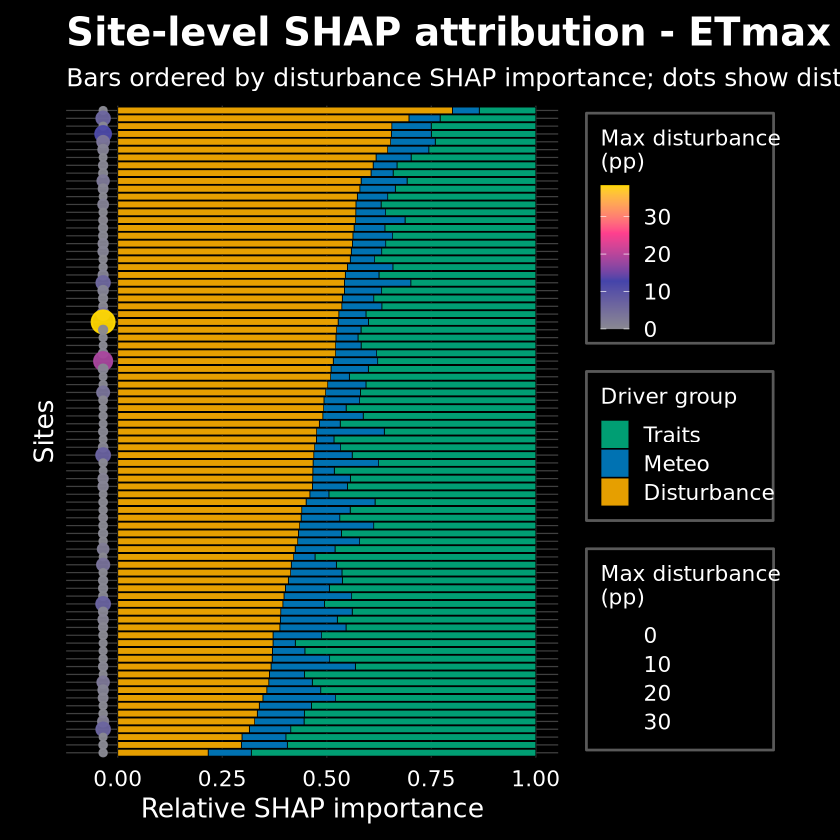

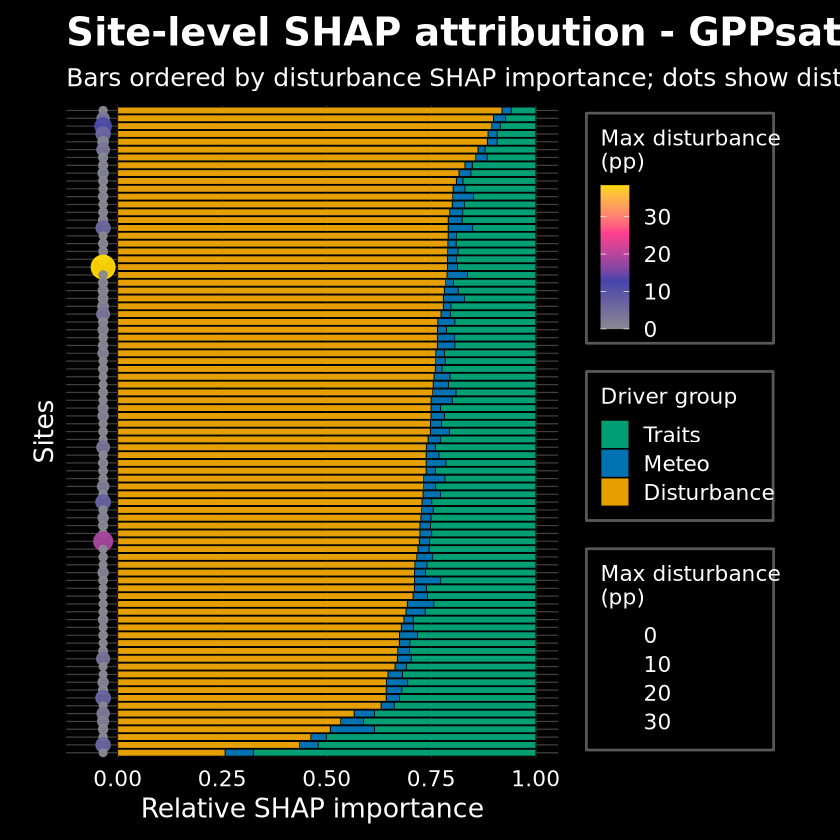

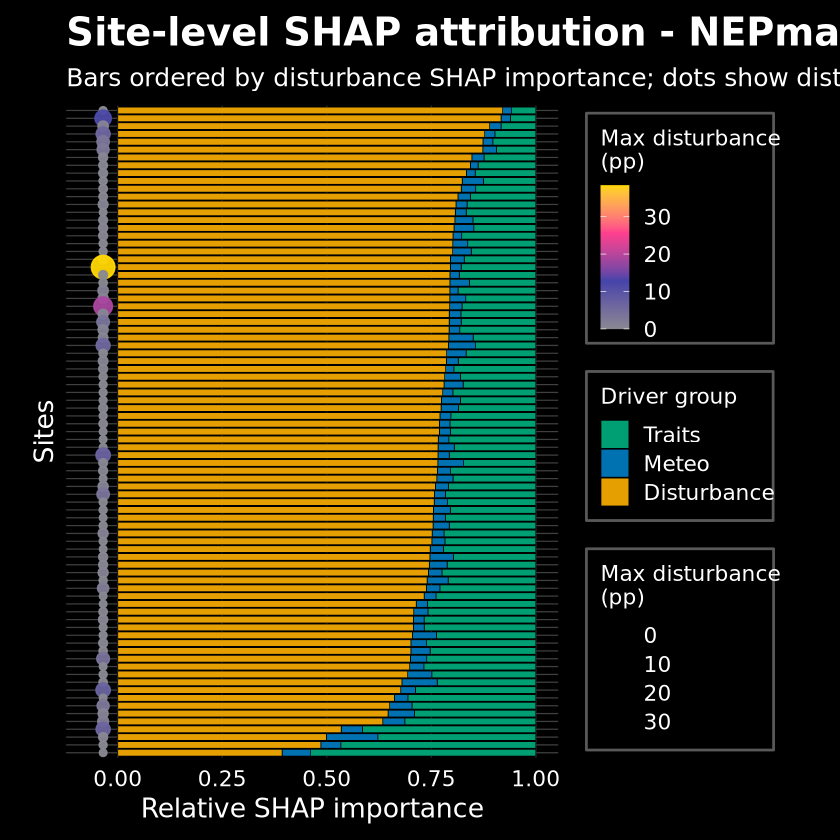

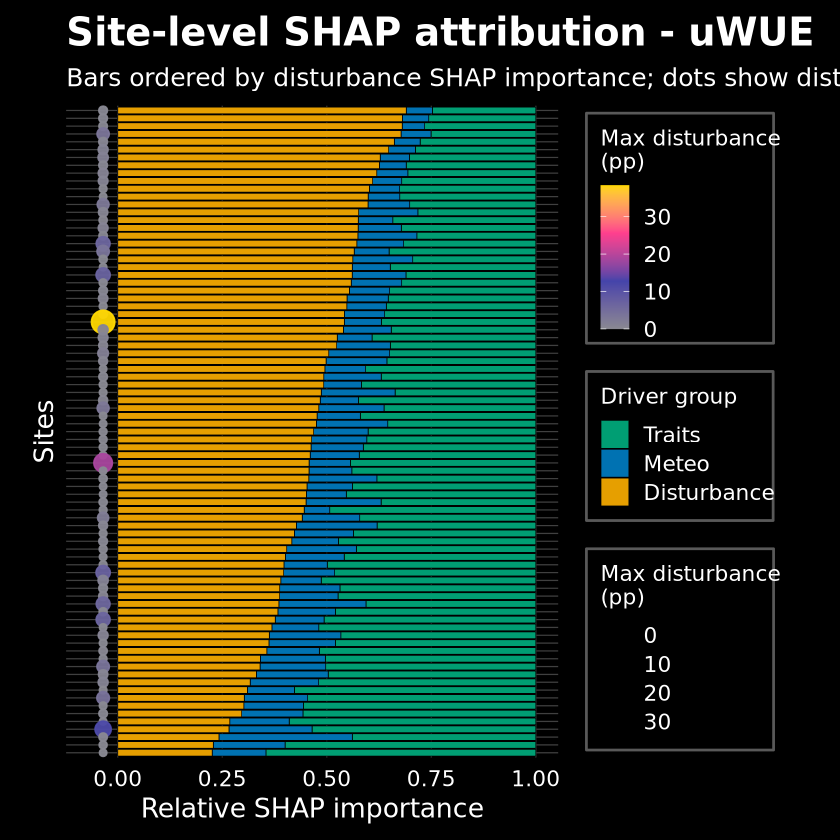

In [27]:
#### Dot instead of site_ID
library(data.table)
library(ggplot2)

# =========================================================
# Plot site-level SHAP attribution for new M04:
# Meteo + Traits + Disturbance
# Disturbance = forest cover + forest loss + deadwood, t/t-1/t-2
# Dots show max disturbance intensity
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
shap_dir <- file.path(out_dir, "shap_M04_meteo_traits_disturbance")
dir.create(shap_dir, recursive = TRUE, showWarnings = FALSE)

shap_simple <- fread(
  file.path(shap_dir, "M04_SHAP_group_importance_per_site.csv")
)

dist_site_class <- fread(
  file.path(out_dir, "site_mean_disturbance_83sites.csv")
)

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

# =========================================================
# Merge SHAP groups:
# Forest cover + disturbance current + disturbance legacy
# into one clean "Disturbance" group
# =========================================================

shap_simple[, group_merged := fifelse(
  group %in% c("Forest cover", "Disturbance current", "Disturbance legacy"),
  "Disturbance",
  as.character(group)
)]

shap_plot <- shap_simple[, .(
  mean_abs_shap = sum(mean_abs_shap, na.rm = TRUE),
  rel_importance = sum(rel_importance, na.rm = TRUE)
), by = .(response, SITE_ID, group = group_merged)]

shap_plot[, group := factor(
  group,
  levels = c("Traits", "Meteo", "Disturbance")
)]

shap_cols_dark <- c(
  "Traits" = "#009E73",
  "Meteo" = "#0072B2",
  "Disturbance" = "#E69F00"
)

# =========================================================
# Prepare disturbance table
# Expected columns: mean_disturbance, max_disturbance, disturbance_class
# =========================================================

if (!("max_disturbance" %in% names(dist_site_class))) {
  stop("Column 'max_disturbance' not found in disturbance table.")
}

if (!("disturbance_class" %in% names(dist_site_class))) {
  dist_site_class[, disturbance_class := fifelse(
    max_disturbance >= 2,
    "High disturbance",
    "Low disturbance"
  )]
}

dist_site_class[, disturbance_score := max_disturbance]

dist_site_class[, disturbance_class := fifelse(
  grepl("High", disturbance_class),
  "High disturbance",
  "Low disturbance"
)]

# =========================================================
# Continuous disturbance color scale
# =========================================================

dist_palette <- c("#898992", "#4444aa", "#FF3F8E", "#FFD700")  # dark → bright

for (resp_use in response_vars) {
  
  plot_dt <- copy(shap_plot[response == resp_use])
  
  site_order <- plot_dt[group == "Disturbance",
    .(disturbance_shap_importance = mean(rel_importance, na.rm = TRUE)),
    by = SITE_ID
  ][order(-disturbance_shap_importance)]
  
  site_order <- merge(
    site_order,
    dist_site_class[, .(
      SITE_ID,
      mean_disturbance,
      max_disturbance
    )],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  # fill missing
  site_order[is.na(max_disturbance), max_disturbance := 0]
  
  site_order <- site_order[order(-disturbance_shap_importance)]
  site_order[, site_rank := .I]
  site_order[, site_rank_f := factor(site_rank, levels = rev(site_rank))]
  
  plot_dt <- merge(
    plot_dt,
    site_order[, .(
      SITE_ID,
      site_rank,
      site_rank_f,
      max_disturbance
    )],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  dot_dt <- unique(site_order[, .(
    site_rank_f,
    max_disturbance
  )])
  
  p <- ggplot(plot_dt, aes(x = rel_importance, y = site_rank_f, fill = group)) +
    
    geom_col(width = 0.85, color = "black", linewidth = 0.2) +
    
    geom_point(
      data = dot_dt,
      aes(
        x = -0.035,
        y = site_rank_f,
        size = max_disturbance,
        color = max_disturbance
      ),
      inherit.aes = FALSE,
      alpha = 0.95
    ) +
    
    scale_fill_manual(values = shap_cols_dark) +
    
    # 🔥 continuous color scale
    scale_color_gradientn(
      colors = dist_palette,
      name = "Max disturbance\n(pp)"
    ) +
    
    scale_size_continuous(
      range = c(1.5, 6),
      name = "Max disturbance\n(pp)"
    ) +
    
    coord_cartesian(xlim = c(-0.07, 1), clip = "off") +
    
    labs(
      title = paste("Site-level SHAP attribution -", resp_use),
      subtitle = "Bars ordered by disturbance SHAP importance; dots show disturbance intensity",
      x = "Relative SHAP importance",
      y = "Sites",
      fill = "Driver group"
    ) +
    
    theme_minimal(base_size = 17) +
    theme(
      plot.background = element_rect(fill = "black", color = NA),
      panel.background = element_rect(fill = "black", color = NA),
      panel.grid.major = element_line(color = "grey25", linewidth = 0.35),
      panel.grid.minor = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      axis.text.x = element_text(size = 13, color = "white"),
      axis.title = element_text(size = 16, color = "white"),
      plot.title = element_text(size = 23, face = "bold", color = "white"),
      plot.subtitle = element_text(size = 15, color = "white"),
      legend.background = element_rect(fill = "black", color = "grey35"),
      legend.key = element_rect(fill = "black", color = NA),
      legend.text = element_text(size = 13, color = "white"),
      legend.title = element_text(size = 13, color = "white"),
      legend.position = "right",
      plot.margin = margin(10, 40, 10, 20)
    )
  
  print(p)


  
  ggsave(
    file.path(shap_dir, paste0("plot_M04_site_SHAP_mergedDisturbance_dotContin_", resp_use, ".pdf")),
    p,
    width = 11,
    height = 13,
    bg = "black"
  )
  
  ggsave(
    file.path(shap_dir, paste0("plot_M04_site_SHAP_mergedDisturbance_dotContin_", resp_use, ".png")),
    p,
    width = 11,
    height = 13,
    dpi = 300,
    bg = "black"
  )
}

In [6]:
# the new version with 13 high disturbed sites
library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_multibuffer"
shap_dir <- file.path(out_dir, "shap_M04_meteo_traits_disturbanceLag_imputed")

shap_simple <- fread(
  file.path(shap_dir, "M04_SHAP_group_importance_per_site.csv")
)

dist_site_class <- fread(
  "derived_tables/final_results_3yr/top13_high_distubed_sites.csv"
)

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

# =========================================================
# Merge current + legacy disturbance into one group
# =========================================================

shap_simple[, group_merged := fifelse(
  group %in% c("Disturbance current", "Disturbance legacy"),
  "Disturbance",
  as.character(group)
)]

shap_simple_merged <- shap_simple[, .(
  mean_abs_shap = sum(mean_abs_shap, na.rm = TRUE),
  rel_importance = sum(rel_importance, na.rm = TRUE)
), by = .(response, SITE_ID, group = group_merged)]

shap_simple_merged[, group := factor(
  group,
  levels = c("Traits", "Meteo", "Disturbance")
)]

shap_cols_dark <- c(
  "Traits" = "#009E73",
  "Meteo" = "#0072B2",
  "Disturbance" = "#E69F00"
)

dist_cols <- c(
  "High disturbance" = "#CC79A7",
  "Low disturbance" = "#56B4E9"
)

dist_site_class[, disturbance_class := fifelse(
  high_dist == TRUE,
  "High disturbance",
  "Low disturbance"
)]

dist_site_class[, disturbance_score := score]

for (resp_use in response_vars) {
  
  plot_dt <- copy(shap_simple_merged[response == resp_use])
  
  site_order <- plot_dt[group == "Disturbance",
    .(disturbance_importance = mean(rel_importance, na.rm = TRUE)),
    by = SITE_ID
  ][order(-disturbance_importance)]
  
  site_order <- merge(
    site_order,
    dist_site_class[, .(
      SITE_ID,
      disturbance_score,
      disturbance_class,
      rank,
      loss_sum_max,
      dw_inc_max,
      dw_mean_max
    )],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  site_order[is.na(disturbance_class), disturbance_class := "Low disturbance"]
  site_order[is.na(disturbance_score), disturbance_score := 0]
  
  site_order <- site_order[order(-disturbance_importance)]
  site_order[, site_rank := .I]
  site_order[, site_rank_f := factor(site_rank, levels = rev(site_rank))]
  
  plot_dt <- merge(
    plot_dt,
    site_order[, .(
      SITE_ID,
      site_rank,
      site_rank_f,
      disturbance_score,
      disturbance_class
    )],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  dot_dt <- unique(site_order[, .(
    site_rank_f,
    disturbance_score,
    disturbance_class
  )])
  
  p <- ggplot(plot_dt, aes(x = rel_importance, y = site_rank_f, fill = group)) +
    geom_col(width = 0.85, color = "black", linewidth = 0.2) +
    geom_point(
      data = dot_dt,
      aes(
        x = -0.035,
        y = site_rank_f,
        size = disturbance_score,
        color = disturbance_class
      ),
      inherit.aes = FALSE,
      alpha = 0.95
    ) +
    scale_fill_manual(values = shap_cols_dark, drop = FALSE) +
    scale_color_manual(values = dist_cols, drop = FALSE) +
    scale_size_continuous(
      range = c(1.5, 6),
      name = "Disturbance\nscore"
    ) +
    coord_cartesian(xlim = c(-0.07, 1), clip = "off") +
    labs(
      title = paste("Site-level SHAP attribution -", resp_use),
      subtitle = "Bars ordered by disturbance SHAP importance; dots identify high-disturbance sites",
      x = "Relative SHAP importance",
      y = "Sites",
      fill = "Driver group",
      color = "Disturbance class"
    ) +
    theme_minimal(base_size = 17) +
    theme(
      plot.background = element_rect(fill = "black", color = NA),
      panel.background = element_rect(fill = "black", color = NA),
      panel.grid.major = element_line(color = "grey25", linewidth = 0.35),
      panel.grid.minor = element_blank(),
      axis.text.y = element_blank(),
      axis.ticks.y = element_blank(),
      axis.text.x = element_text(size = 13, color = "white"),
      axis.title = element_text(size = 16, color = "white"),
      plot.title = element_text(size = 23, face = "bold", color = "white"),
      plot.subtitle = element_text(size = 15, color = "white"),
      legend.background = element_rect(fill = "black", color = "grey35"),
      legend.key = element_rect(fill = "black", color = NA),
      legend.text = element_text(size = 13, color = "white"),
      legend.title = element_text(size = 13, color = "white"),
      legend.position = "right",
      plot.margin = margin(10, 40, 10, 20)
    )
  
  ggsave(
    file.path(shap_dir, paste0("plot_M04_site_SHAP_dot_highdist_mergedDisturbance_", resp_use, ".pdf")),
    p,
    width = 11,
    height = 13,
    bg = "black"
  )
  
  ggsave(
    file.path(shap_dir, paste0("plot_M04_site_SHAP_dot_highdist_mergedDisturbance_", resp_use, ".png")),
    p,
    width = 11,
    height = 13,
    dpi = 300,
    bg = "black"
  )
}

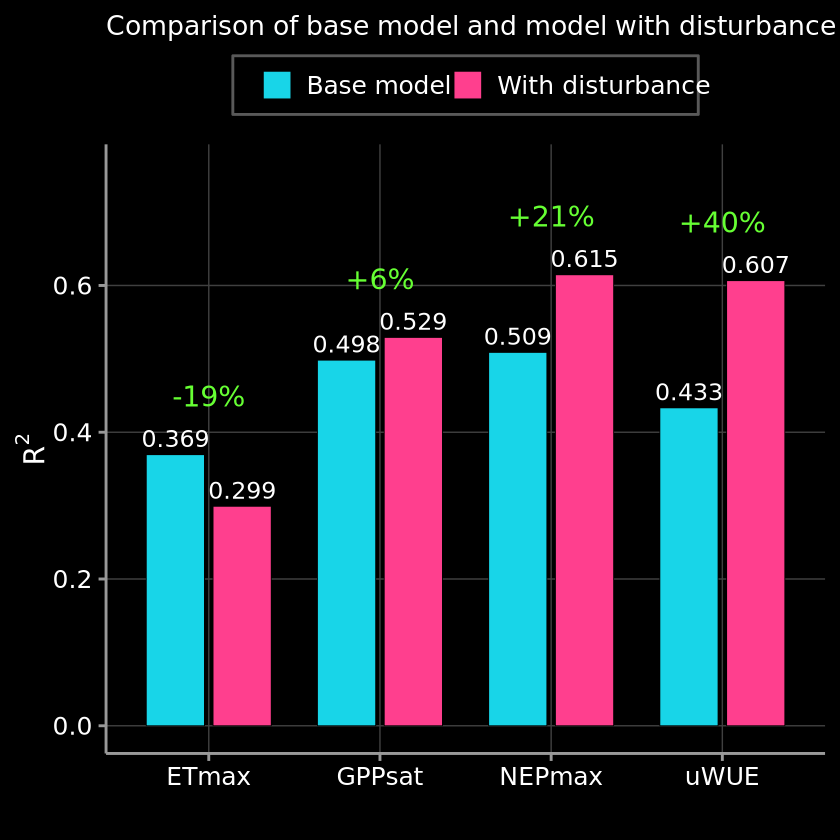

In [4]:
# =========================================================
# STEP 3: R2 bar plot for M02 vs M04 only
# Dark style + color code + percent improvement labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_multibuffer/EFP_batch_metrics_ALL_3yr_disturbanceLag_memory_context.csv"
)

efp_keep <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

metrics_m2m4 <- metrics[
  response %in% efp_keep &
    (grepl("^M03_", model) | grepl("^M04_", model))
]

metrics_m2m4[, model_group := fifelse(
  grepl("^M03_", model),
  "Base model",
  "With disturbance"
)]

metrics_m2m4[, model_group := factor(
  model_group,
  levels = c("Base model", "With disturbance")
)]

metrics_m2m4[, response := factor(
  response,
  levels = c("ETmax", "GPPsat", "NEPmax", "uWUE")
)]

bar_cols <- c(
  "Base model" = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

r2_wide <- dcast(
  metrics_m2m4,
  response ~ model_group,
  value.var = "R2"
)

r2_wide[, delta_R2 := `With disturbance` - `Base model`]

r2_wide[, pct_improvement := 100 * delta_R2 / `Base model`]

r2_wide[, label := paste0(
  ifelse(pct_improvement >= 0, "+", ""),
  sprintf("%.0f", pct_improvement),
  "%"
)]

label_dt <- merge(
  r2_wide[, .(response, delta_R2, pct_improvement, label)],
  metrics_m2m4[, .(ymax = max(R2, na.rm = TRUE)), by = response],
  by = "response"
)

label_dt[, y_pos := ymax + 0.08]

p_r2_dark <- ggplot(metrics_m2m4, aes(x = response, y = R2, fill = model_group)) +
  geom_col(
    position = position_dodge(width = 0.78),
    width = 0.68,
    color = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", R2)),
    position = position_dodge(width = 0.78),
    vjust = -0.45,
    size = 5,
    color = "white"
  ) +
  geom_text(
    data = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6,
    #fontface = "bold",
    color = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) + 0.06)
  ) +
  labs(
    #title = "Does deadwood improve model performance?",
    subtitle = "Comparison of base model and model with disturbance",
    x = "",
    y = expression(R^2),
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    panel.grid.major = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    axis.text = element_text(size = 15, color = "white"),
    axis.title = element_text(size = 17, color = "white"),
    legend.text = element_text(size = 15, color = "white"),
    legend.position = "top"
  )


print(p_r2_dark)

ggsave(
  file.path(out_dir, "plot_R2_M03_vs_M04_deadwood_dark.pdf"),
  p_r2_dark,
  width = 10,
  height = 6,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_R2_M03_vs_M04_deadwood_dark.png"),
  p_r2_dark,
  width = 10,
  height = 6,
  dpi = 300,
  bg = "black"
)

In [6]:
install.packages("remotes")
remotes::install_github("thomasp85/patchwork")

Installing package into ‘/home/nk1125/miniconda3/envs/clean_r_env/lib/R/library’
(as ‘lib’ is unspecified)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




rlang       (1.1.6 -> 1.2.0) [CRAN]
cli         (3.6.5 -> 3.6.6) [CRAN]
lifecycle   (1.0.4 -> 1.0.5) [CRAN]
glue        (1.8.0 -> 1.8.1) [CRAN]
viridisLite (0.4.2 -> 0.4.3) [CRAN]
cpp11       (0.5.2 -> 0.5.4) [CRAN]
vctrs       (0.6.5 -> 0.7.3) [CRAN]
S7          (0.2.1 -> 0.2.2) [CRAN]
isoband     (0.2.7 -> 0.3.0) [CRAN]
ggplot2     (3.5.1 -> 4.0.3) [CRAN]


Installing 10 packages: rlang, cli, lifecycle, glue, viridisLite, cpp11, vctrs, S7, isoband, ggplot2

Installing packages into ‘/home/nk1125/miniconda3/envs/clean_r_env/lib/R/library’
(as ‘lib’ is unspecified)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpjGb3h1/remotes31eabf49cb8263/thomasp85-patchwork-6b1d88c/DESCRIPTION’ ... OK
* preparing ‘patchwork’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘patchwork_1.3.2.9000.tar.gz’



Installing package into ‘/home/nk1125/miniconda3/envs/clean_r_env/lib/R/library’
(as ‘lib’ is unspecified)



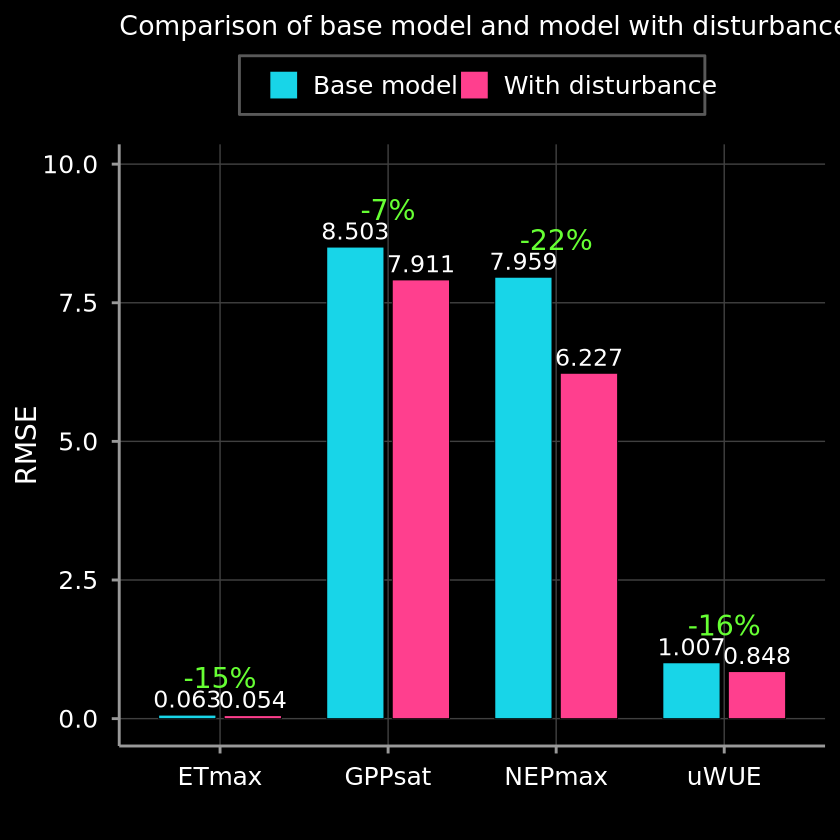

In [7]:
# =========================================================
# STEP 3b: RMSE bar plot for M03 vs M04 only
# Dark style + color code + percent reduction labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_EGU"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_multibuffer/EFP_batch_metrics_ALL_3yr_disturbanceLag_memory_context.csv"
)

efp_keep <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

metrics_m3m4 <- metrics[
  response %in% efp_keep &
    (grepl("^M03_", model) | grepl("^M04_", model))
]

metrics_m3m4[, model_group := fifelse(
  grepl("^M03_", model),
  "Base model",
  "With disturbance"
)]

metrics_m3m4[, model_group := factor(
  model_group,
  levels = c("Base model", "With disturbance")
)]

metrics_m3m4[, response := factor(
  response,
  levels = c("ETmax", "GPPsat", "NEPmax", "uWUE")
)]

bar_cols <- c(
  "Base model" = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

rmse_wide <- dcast(
  metrics_m3m4,
  response ~ model_group,
  value.var = "RMSE"
)

# For RMSE, lower is better
rmse_wide[, delta_RMSE := `With disturbance` - `Base model`]

rmse_wide[, pct_change := 100 * delta_RMSE / `Base model`]

rmse_wide[, label := paste0(
  ifelse(pct_change <= 0, "", "+"),
  sprintf("%.0f", pct_change),
  "%"
)]

label_dt <- merge(
  rmse_wide[, .(response, delta_RMSE, pct_change, label)],
  metrics_m3m4[, .(ymax = max(RMSE, na.rm = TRUE)), by = response],
  by = "response"
)

label_dt[, y_pos := ymax + 0.08 * max(metrics_m3m4$RMSE, na.rm = TRUE)]

p_rmse_dark <- ggplot(metrics_m3m4, aes(x = response, y = RMSE, fill = model_group)) +
  geom_col(
    position = position_dodge(width = 0.78),
    width = 0.68,
    color = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", RMSE)),
    position = position_dodge(width = 0.78),
    vjust = -0.45,
    size = 5,
    color = "white"
  ) +
  geom_text(
    data = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6,
    color = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) + 0.08 * max(metrics_m3m4$RMSE, na.rm = TRUE))
  ) +
  labs(
    subtitle = "Comparison of base model and model with disturbance",
    x = "",
    y = "RMSE",
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    panel.grid.major = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    axis.text = element_text(size = 15, color = "white"),
    axis.title = element_text(size = 17, color = "white"),
    legend.text = element_text(size = 15, color = "white"),
    legend.position = "top"
  )

print(p_rmse_dark)

ggsave(
  file.path(out_dir, "plot_RMSE_M03_vs_M04_disturbance_dark.pdf"),
  p_rmse_dark,
  width = 10,
  height = 6,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_RMSE_M03_vs_M04_disturbance_dark.png"),
  p_rmse_dark,
  width = 10,
  height = 6,
  dpi = 300,
  bg = "black"
)

In [ ]:
# ============================================================
# Disturbance characterisation across 52 flux tower sites
# ============================================================
library(data.table)
library(dplyr)
library(ggplot2)
library(tidyr)
library(cowplot)
#library(patchwork)
library(ggrepel)

# ---- 0. Theme ---------------------------------------------------
BG       <- "black"
FG       <- "white"
GRID     <- "#2a2a2a"
HIGH_COL <- "#FF4488"
LOW_COL  <- "#20C8C8"

dark_theme <- theme(
  plot.background   = element_rect(fill = BG, color = NA),
  panel.background  = element_rect(fill = "#0d0d0d", color = NA),
  panel.grid.major  = element_line(color = GRID, linewidth = 0.3),
  panel.grid.minor  = element_blank(),
  axis.text         = element_text(color = FG, size = 7),
  axis.title        = element_text(color = FG, size = 9),
  plot.title        = element_text(color = FG, size = 10, face = "bold"),
  legend.background = element_rect(fill = "#1a1a1a", color = GRID),
  legend.text       = element_text(color = FG, size = 8),
  legend.title      = element_text(color = FG, size = 8),
  axis.ticks        = element_line(color = GRID),
  strip.background  = element_rect(fill = "#1a1a1a"),
  strip.text        = element_text(color = FG)
)

# ---- 1. Load data -----------------------------------------------
df <- fread("derived_tables/final_results_3yr_multibuffer/modeldata_MASTER_complete_3yr_with_disturbance_lag1_lag2_lag3_used.csv")

# ---- 2. Site-level summary (max across years, 500 m) ------------
site_stats <- df %>%
  group_by(SITE_ID) %>%
  summarise(
    loss_sum_max  = max(loss_sum_pp_500m,           na.rm = TRUE),
    dw_inc_max    = max(deadwood_increase_sum_pp_500m, na.rm = TRUE),
    dw_mean_max   = max(deadwood_mean_pct_500m,     na.rm = TRUE),
    .groups = "drop"
  )

# Normalise to [0,1] and compute composite score
norm01 <- function(x) (x - min(x, na.rm=TRUE)) / (max(x, na.rm=TRUE) - min(x, na.rm=TRUE) + 1e-9)

site_stats <- site_stats %>%
  mutate(
    score = norm01(loss_sum_max) * 0.33 +
            norm01(dw_inc_max)   * 0.33 +
            norm01(dw_mean_max)  * 0.33
  ) %>%
  arrange(desc(score)) %>%
  mutate(
    high_dist = score >= quantile(score, 0.75),
    dist_type = case_when(
      high_dist ~ "High disturbance",
      TRUE      ~ "Low disturbance"
    ),
    rank = row_number()
  )

q75_val   <- quantile(site_stats$score, 0.75)
high_sites <- site_stats$SITE_ID[site_stats$high_dist]

cat("High-disturbance sites (top 25%):\n")
print(high_sites)

# ---- 3. Panel A — Heatmap (site x year) -------------------------
heat_long <- df %>%
  select(SITE_ID, year, loss_sum_pp_500m) %>%
  group_by(SITE_ID, year) %>%
  summarise(value = max(loss_sum_pp_500m, na.rm = TRUE), .groups = "drop")

# Order sites by composite score
site_order <- rev(site_stats$SITE_ID)   # rev so highest is at top
heat_long <- heat_long %>%
  mutate(
    SITE_ID   = factor(SITE_ID, levels = site_order),
    high_dist = SITE_ID %in% high_sites
  )

# Clip colour scale at 95th percentile
cap95 <- quantile(heat_long$value, 0.95, na.rm = TRUE)
heat_long$value_capped <- pmin(heat_long$value, cap95)

# # Plot Panel A: heatmap of capped disturbance per site per year
pA <- ggplot(heat_long, aes(x = factor(year), y = SITE_ID, fill = value_capped)) +
  geom_tile(color = NA) +
  scale_fill_gradient(
    low  = "#1a1a1a",
    high = "#FF6600",
    name = "loss_sum_pp",
    labels = scales::comma
  ) +
  labs(
    title = "A  Forest loss (loss_sum_pp_500m) per site × year",
    x = "Year", y = NULL
  ) +
  dark_theme +
  theme(
    axis.text.y     = element_text(size = 5.5, colour = FG),
    legend.position = "right"
  )

# ---- 4. Panel B — Scatter (loss vs deadwood increase) -----------
# Spearman correlation
sp_r <- cor(site_stats$loss_sum_max, site_stats$dw_inc_max,
            method = "spearman", use = "complete.obs")
sp_p <- cor.test(site_stats$loss_sum_max, site_stats$dw_inc_max,
                 method = "spearman")$p.value

top8 <- site_stats %>% slice_head(n = 8)

pB <- ggplot(site_stats, aes(x = loss_sum_max, y = dw_inc_max, color = dist_type)) +
  geom_point(size = 3, alpha = 0.85) +
  geom_text_repel(
    data = top8,
    aes(label = SITE_ID),
    size = 2.8, color = FG,
    box.padding = 0.3, max.overlaps = 20
  ) +
  scale_color_manual(
    values = c("High disturbance" = HIGH_COL, "Low disturbance" = LOW_COL),
    name   = NULL
  ) +
  annotate("text",
    x = Inf, y = -Inf,
    label = sprintf("Spearman r = %.2f\np = %.3f", sp_r, sp_p),
    hjust = 1.05, vjust = -0.3,
    color = "grey60", size = 3
  ) +
  scale_x_continuous(labels = scales::comma) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "B  Forest loss vs Deadwood increase",
    x = "max loss_sum_pp_500m",
    y = "max deadwood_increase_sum_pp_500m"
  ) +
  dark_theme +
  theme(legend.position.inside = c(0.75, 0.88),
      legend.justification    = c(1, 1))

# ---- 5. Panel C — Composite score bar chart ----------------------
site_stats_plot <- site_stats %>%
  mutate(SITE_ID = factor(SITE_ID, levels = rev(site_stats$SITE_ID)))

pC <- ggplot(site_stats_plot, aes(x = score, y = SITE_ID, fill = dist_type)) +
  geom_col(width = 0.7, alpha = 0.85) +
  geom_vline(xintercept = q75_val, color = FG, linetype = "dashed", linewidth = 0.8) +
  annotate("text",
    x = q75_val + 0.005, y = 3,
    label = sprintf("Q75 = %.3f", q75_val),
    color = FG, size = 3, hjust = 0
  ) +
  scale_fill_manual(
    values = c("High disturbance" = HIGH_COL, "Low disturbance" = LOW_COL),
    name   = NULL
  ) +
  scale_y_discrete() +
  labs(
    title = "C  Site ranking by composite score\n(0.5 × loss + 0.4 × dw_inc + 0.1 × dw_mean)",
    x = "Composite disturbance score",
    y = NULL
  ) +
  dark_theme +
  theme(legend.position.inside = c(0.75, 0.15),
      legend.justification    = c(1, 0))

# ---- 6. Panel D — Buffer sensitivity ----------------------------
buffers <- c(100, 200, 300, 400, 500)

buf_long <- lapply(buffers, function(b) {
  df %>%
    group_by(SITE_ID) %>%
    summarise(loss_max = max(.data[[paste0("loss_sum_pp_", b, "m")]], na.rm = TRUE),
              .groups = "drop") %>%
    mutate(buffer = b)
}) %>% bind_rows()

# Normalise per site (site max across all buffers = 1)
buf_long <- buf_long %>%
  group_by(SITE_ID) %>%
  mutate(loss_norm = loss_max / (max(loss_max, na.rm = TRUE) + 1e-9)) %>%
  ungroup() %>%
  mutate(
    high_dist = SITE_ID %in% high_sites,
    dist_type = ifelse(high_dist, "High disturbance", "Low disturbance")
  )

pD <- ggplot(buf_long, aes(x = buffer, y = loss_norm,
                            group = SITE_ID, color = dist_type,
                            alpha = dist_type)) +
  geom_line(linewidth = 0.8) +
  scale_color_manual(
    values = c("High disturbance" = HIGH_COL, "Low disturbance" = LOW_COL),
    name   = NULL
  ) +
  scale_alpha_manual(
    values = c("High disturbance" = 0.75, "Low disturbance" = 0.2),
    guide  = "none"
  ) +
  scale_x_continuous(breaks = buffers) +
  labs(
    title = "D  Buffer sensitivity of forest loss",
    x     = "Buffer radius (m)",
    y     = "Normalised loss_sum_pp\n(per-site max = 1)"
  ) +
  dark_theme +
  theme(legend.position.inside = c(0.25, 0.88),
      legend.justification    = c(0, 1))

# ---- 7. Combine & save ------------------------------------------
library(cowplot)

title_grob <- ggdraw() +
  draw_label(
    "Disturbance characterisation across 52 flux tower sites",
    fontface = "bold", size = 13, color = FG,
    x = 0.5, hjust = 0.5
  ) +
  theme(plot.background = element_rect(fill = BG, color = NA))

top_row    <- plot_grid(pA, pB, ncol = 2, rel_widths = c(1.4, 1))
bottom_row <- plot_grid(pC, pD, ncol = 2, rel_widths = c(1.4, 1))
main       <- plot_grid(top_row, bottom_row, nrow = 2)
final_plot <- plot_grid(title_grob, main, nrow = 2, rel_heights = c(0.04, 1))

ggsave(
  "disturbance_visualisation01.png",
  final_plot,
  width  = 20,
  height = 14,
  dpi    = 200,
  bg     = BG
)

ggsave(
  "disturbance_visualisation01.pdf",
  final_plot,
  width  = 20,
  height = 14,
  units  = "in",
  device = cairo_pdf,   # better font rendering than default pdf()
  bg     = BG
)
cat("Saved: disturbance_visualisation01.png\n")
cat("Saved: disturbance_visualisation01.pdf\n")

High-disturbance sites (top 25%):
 [1] "AU-War" "IT-Lav" "CZ-RAJ" "US-xSC" "US-xHA" "DE-Hte" "US-xML" "US-GLE"
 [9] "RU-Fyo" "CA-TPD" "IT-TrF" "CZ-Stn" "US-xTR"


Warning message in cor.test.default(site_stats$loss_sum_max, site_stats$dw_inc_max, :
“Cannot compute exact p-value with ties”


Saved: disturbance_visualisation01.png
Saved: disturbance_visualisation01.pdf


In [19]:
# ---- Step 1: Create the data objects -------------------------
heat_loss <- df %>%
  group_by(SITE_ID, year) %>%
  summarise(value = max(loss_sum_pp_500m, na.rm = TRUE), .groups = "drop") %>%
  mutate(metric = "Forest loss\n(loss_sum_pp_500m)")

heat_dw <- df %>%
  group_by(SITE_ID, year) %>%
  summarise(value = max(deadwood_increase_sum_pp_500m, na.rm = TRUE), .groups = "drop") %>%
  mutate(metric = "Deadwood increase\n(dw_increase_sum_pp_500m)")

# ---- Step 2: Build the two heatmap plots ---------------------
pA_loss <- ggplot(
    heat_loss %>% mutate(SITE_ID = factor(SITE_ID, levels = site_order)),
    aes(x = factor(year), y = SITE_ID,
        fill = pmin(value, quantile(value, 0.95, na.rm = TRUE)))
  ) +
  geom_tile() +
  scale_fill_gradient(
    low  = "#1a1a1a", high = "#FF6600",
    name = "loss_sum_pp", labels = scales::comma
  ) +
  labs(title = "Forest loss", x = "Year", y = NULL) +
  dark_theme +
  theme(
    axis.text.y     = element_text(size = 5.5, colour = FG),
    legend.position = "right"
  )

pA_dw <- ggplot(
    heat_dw %>% mutate(SITE_ID = factor(SITE_ID, levels = site_order)),
    aes(x = factor(year), y = SITE_ID,
        fill = pmin(value, quantile(value, 0.95, na.rm = TRUE)))
  ) +
  geom_tile() +
  scale_fill_gradient(
    low  = "#1a1a1a", high = "#20C8C8",
    name = "dw_inc_sum_pp", labels = scales::comma
  ) +
  labs(title = "Deadwood increase", x = "Year", y = NULL) +
  dark_theme +
  theme(
    axis.text.y  = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = "right"
  )

# ---- Step 3: Combine into pA ---------------------------------
pA <- plot_grid(pA_loss, pA_dw, ncol = 2, rel_widths = c(1.2, 1))

# ---- Step 4: Final assembly ----------------------------------
title_grob <- ggdraw() +
  draw_label(
    "Disturbance characterisation across 52 flux tower sites",
    fontface = "bold", size = 13, color = FG,
    x = 0.5, hjust = 0.5
  ) +
  theme(plot.background = element_rect(fill = BG, color = NA))

top_row    <- plot_grid(pA, pB, ncol = 2, rel_widths = c(1.6, 1))
bottom_row <- plot_grid(pC, pD, ncol = 2, rel_widths = c(1.4, 1))
main       <- plot_grid(top_row, bottom_row, nrow = 2)
final_plot <- plot_grid(title_grob, main, nrow = 2, rel_heights = c(0.04, 1))

ggsave(
  "disturbance_visualisation02.png",
  final_plot,
  width  = 20,
  height = 14,
  dpi    = 200,
  bg     = BG
)

ggsave(
  "disturbance_visualisation02.pdf",
  final_plot,
  width  = 20,
  height = 14,
  units  = "in",
  device = cairo_pdf,   # better font rendering than default pdf()
  bg     = BG
)

In [ ]:

fwrite(site_stats, "derived_tables/final_results_3yr/top13_high_distubed_sites.csv")

In [ ]:

fwrite(buf_long, "derived_tables/final_results_3yr_multibuffer/high_distubed_sites_eachbuffer.csv")

Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_col()`).”


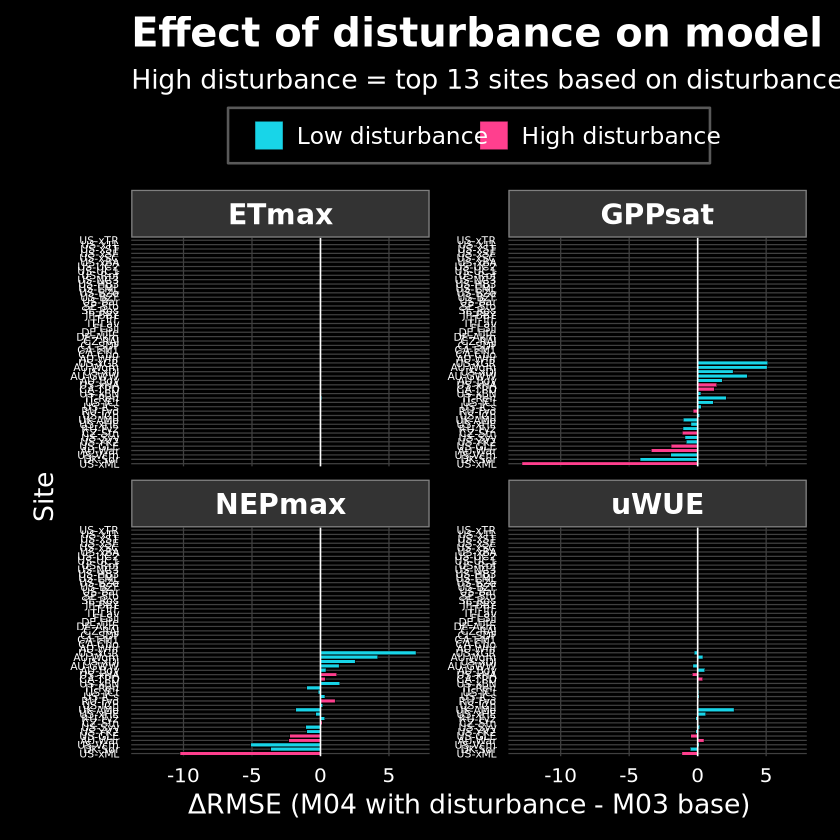

In [ ]:
library(data.table)
library(ggplot2)

# =========================================================
# Site-level ΔRMSE plot: M03 base vs M04 with disturbance
# Color = top 13 high-disturbed sites
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

pred_file <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance/EFP_batch_metrics.csv"

highdist_file <- "derived_tables/final_results_3yr/top13_high_distubed_sites.csv"

pred <- fread(pred_file)
highdist <- fread(highdist_file)

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

# ---------------------------------------------------------
# Keep M03 and M04
# M03 = meteo + traits
# M04 = meteo + traits + disturbance lag
# ---------------------------------------------------------

pred_m3m4 <- pred[
  response %in% response_vars &
    (grepl("^M03_", model) | grepl("^M04_", model))
]

pred_m3m4[, model_group := fifelse(
  grepl("^M03_", model),
  "Base model",
  "With disturbance"
)]

# ---------------------------------------------------------
# Calculate site-level RMSE per response and model
# ---------------------------------------------------------

site_rmse <- pred_m3m4[
  !is.na(observed) & !is.na(predicted),
  .(
    RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
  ),
  by = .(response, SITE_ID, model_group)
]

site_rmse_wide <- dcast(
  site_rmse,
  response + SITE_ID ~ model_group,
  value.var = "RMSE"
)

# Positive value = disturbance model has lower RMSE = improvement
site_rmse_wide[, delta_RMSE := `With disturbance` - `Base model`]

# ---------------------------------------------------------
# Add high-disturbance classification
# ---------------------------------------------------------

highdist[, disturbance_class := fifelse(
  high_dist == TRUE,
  "High disturbance",
  "Low disturbance"
)]

site_rmse_wide <- merge(
  site_rmse_wide,
  highdist[, .(SITE_ID, disturbance_class, score, rank)],
  by = "SITE_ID",
  all.x = TRUE
)

site_rmse_wide[is.na(disturbance_class), disturbance_class := "Low disturbance"]
site_rmse_wide[is.na(score), score := 0]

site_rmse_wide[, disturbance_class := factor(
  disturbance_class,
  levels = c("Low disturbance", "High disturbance")
)]

site_rmse_wide[, response := factor(
  response,
  levels = response_vars
)]

# ---------------------------------------------------------
# Order sites separately within each response by ΔRMSE
# ---------------------------------------------------------

site_rmse_wide <- site_rmse_wide[
  order(response, delta_RMSE)
]

site_rmse_wide[, SITE_ID_f := factor(
  SITE_ID,
  levels = SITE_ID[order(delta_RMSE)]
), by = response]

# Better facet-specific ordering
site_rmse_wide[, site_response := paste(response, SITE_ID, sep = "__")]
site_rmse_wide[, site_response := factor(
  site_response,
  levels = site_response[order(response, delta_RMSE)]
)]

site_rmse_wide[, site_label := SITE_ID]

# ---------------------------------------------------------
# Colors
# ---------------------------------------------------------

dist_cols <- c(
  "Low disturbance" = "#18D5E8",
  "High disturbance" = "#FF3F8E"
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

p_delta_rmse <- ggplot(
  site_rmse_wide,
  aes(
    x = delta_RMSE,
    y = reorder(SITE_ID, delta_RMSE),
    fill = disturbance_class
  )
) +
  geom_col(width = 0.82, color = "black", linewidth = 0.15) +
  geom_vline(xintercept = 0, color = "white", linewidth = 0.45) +
  facet_wrap(
    ~ response,
    scales = "free_y",
    ncol = 2
  ) +
  scale_fill_manual(values = dist_cols, drop = FALSE) +
  labs(
    title = "Effect of disturbance on model performance",
    subtitle = "High disturbance = top 13 sites based on disturbance score",
    x = expression(Delta*"RMSE (M04 with disturbance - M03 base)"),
    y = "Site",
    fill = ""
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    strip.background = element_rect(fill = "grey20", color = "grey50"),
    strip.text = element_text(size = 17, face = "bold", color = "white"),
    
    panel.grid.major = element_line(color = "grey25", linewidth = 0.35),
    panel.grid.minor = element_blank(),
    
    axis.text.x = element_text(size = 12, color = "white"),
    axis.text.y = element_text(size = 6.5, color = "white"),
    axis.title = element_text(size = 16, color = "white"),
    
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    
    legend.position = "top",
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    legend.text = element_text(size = 14, color = "white"),
    
    plot.margin = margin(10, 20, 10, 20)
  )

print(p_delta_rmse)

ggsave(
  file.path(out_dir, "plot_deltaRMSE_M03_vs_M04_highdist_top13_dark.pdf"),
  p_delta_rmse,
  width = 12,
  height = 10,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_deltaRMSE_M03_vs_M04_highdist_top13_dark.png"),
  p_delta_rmse,
  width = 12,
  height = 10,
  dpi = 300,
  bg = "black"
)

Rows : 209 
Sites: 83 


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <89>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'High (≥ 2)' in 'mbcsToSbcs': dot substituted for <a5>”
Warning message in grid.Call.graph

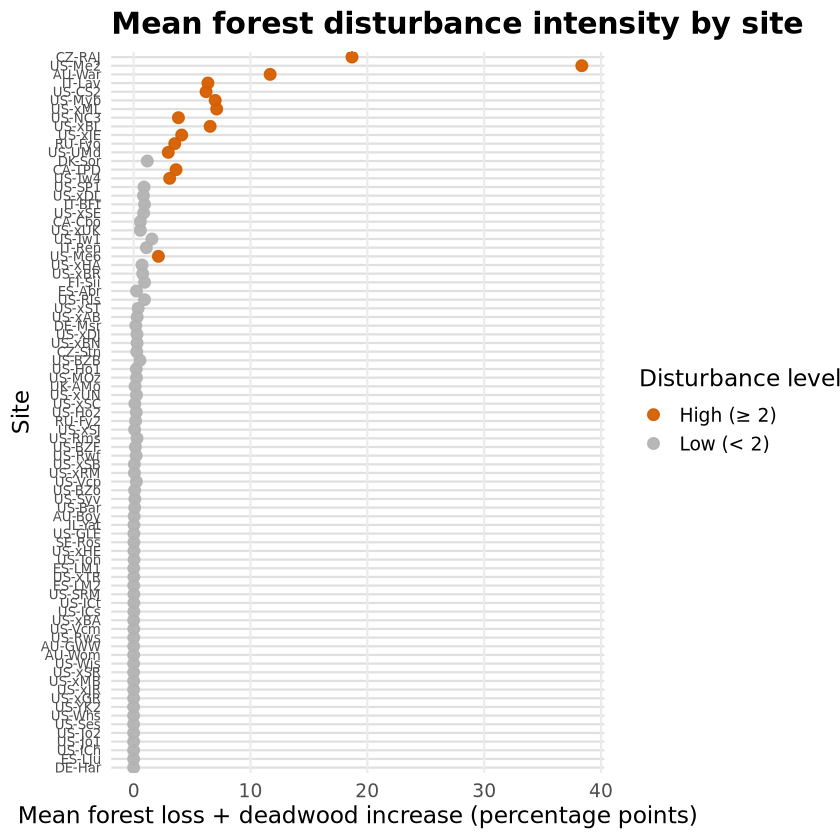

In [17]:
library(data.table)

library(ggplot2)

# =========================================================

# Plot mean disturbance intensity for final 45 sites

# Disturbance = forest loss + deadwood increase

# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread("derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv")

cat("Rows :", nrow(dt), "\n")

cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------

# Disturbance score per site-year

# using 500 m products

# ---------------------------------------------------------

dt[, disturbance_intensity := 

     loss_mean_pp_500m +

     deadwood_increase_mean_pp_500m]

# Alternative, if you prefer area fraction instead:

# dt[, disturbance_intensity :=

#      loss_area_frac_500m * 100 +

#      deadwood_increase_area_frac_500m * 100]

# ---------------------------------------------------------

# Mean disturbance per site

# ---------------------------------------------------------

site_dist <- dt[, .(
  mean_disturbance = mean(disturbance_intensity, na.rm = TRUE),
  max_disturbance  = max(disturbance_intensity, na.rm = TRUE)
), by = SITE_ID]
site_dist <- site_dist[order(mean_disturbance)]
site_dist[, SITE_ID_f := factor(SITE_ID, levels = SITE_ID)]

# define sites with high disturbance
site_dist[, disturbance_class := ifelse(max_disturbance >= 2,
                                        "High (≥ 2)",
                                        "Low (< 2)")]
# save table
fwrite(
  site_dist,
  file.path(out_dir, "site_mean_disturbance_83sites.csv")

)


# ---------------------------------------------------------

# Full site plot

# ---------------------------------------------------------

p_all <- ggplot(site_dist, aes(x = max_disturbance,
                              y = SITE_ID_f,
                              color = disturbance_class)) +

  geom_point(size = 2.8, alpha = 0.95) +

  scale_color_manual(values = c(
    "Low (< 2)" = "grey70",
    "High (≥ 2)" = "#D55E00"   # colorblind-friendly reddish
  )) +

  labs(
    title = "Mean forest disturbance intensity by site",
    x = "Mean forest loss + deadwood increase (percentage points)",
    y = "Site",
    color = "Disturbance level"
  ) +

  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_line(color = "grey88"),
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 8),
    plot.title = element_text(size = 18, face = "bold")
  )

print(p_all)

ggsave(

  file.path(out_dir, "plot_mean_disturbance_all_83sites.pdf"),

  p_all,

  width = 8,

  height = 11
)

ggsave(

  file.path(out_dir, "plot_mean_disturbance_all_83sites.png"),

  p_all,

  width = 8,

  height = 11,

  dpi = 300

)

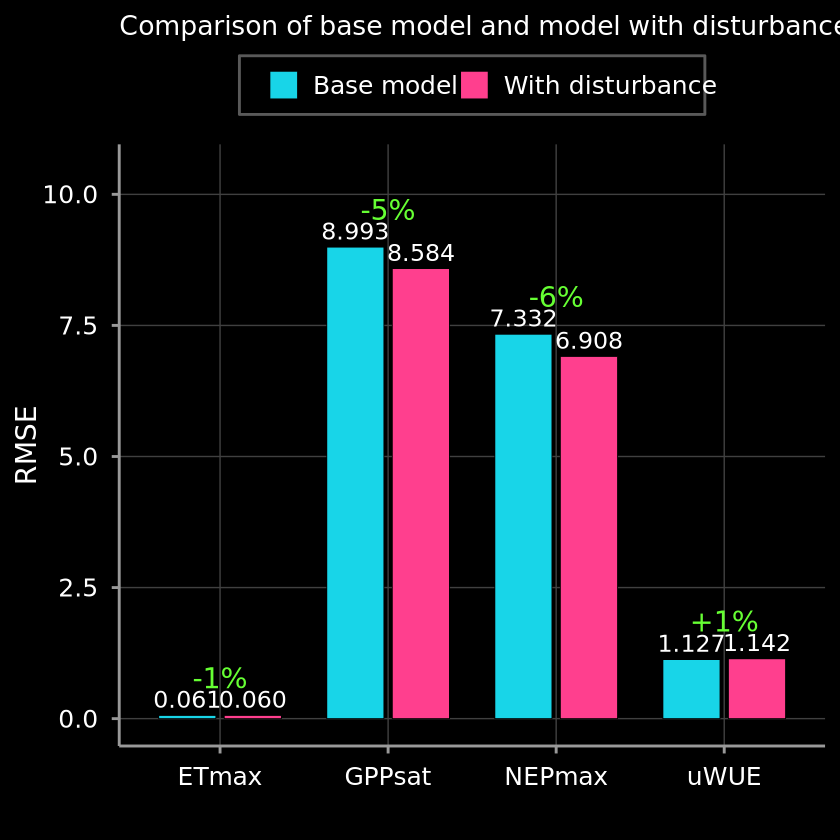

In [13]:
# =========================================================
# STEP 3b: RMSE bar plot for M03 vs M04 only
# Dark style + color code + percent reduction labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance/EFP_batch_metrics.csv"
)

efp_keep <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

metrics_m3m4 <- metrics[
  response %in% efp_keep &
    (grepl("^M03_", model) | grepl("^M04_", model))
]

metrics_m3m4[, model_group := fifelse(
  grepl("^M03_", model),
  "Base model",
  "With disturbance"
)]

metrics_m3m4[, model_group := factor(
  model_group,
  levels = c("Base model", "With disturbance")
)]

metrics_m3m4[, response := factor(
  response,
  levels = c("ETmax", "GPPsat", "NEPmax", "uWUE")
)]

bar_cols <- c(
  "Base model" = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

rmse_wide <- dcast(
  metrics_m3m4,
  response ~ model_group,
  value.var = "RMSE"
)

# For RMSE, lower is better
rmse_wide[, delta_RMSE := `With disturbance` - `Base model`]

rmse_wide[, pct_change := 100 * delta_RMSE / `Base model`]

rmse_wide[, label := paste0(
  ifelse(pct_change <= 0, "", "+"),
  sprintf("%.0f", pct_change),
  "%"
)]

label_dt <- merge(
  rmse_wide[, .(response, delta_RMSE, pct_change, label)],
  metrics_m3m4[, .(ymax = max(RMSE, na.rm = TRUE)), by = response],
  by = "response"
)

label_dt[, y_pos := ymax + 0.08 * max(metrics_m3m4$RMSE, na.rm = TRUE)]

p_rmse_dark <- ggplot(metrics_m3m4, aes(x = response, y = RMSE, fill = model_group)) +
  geom_col(
    position = position_dodge(width = 0.78),
    width = 0.68,
    color = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", RMSE)),
    position = position_dodge(width = 0.78),
    vjust = -0.45,
    size = 5,
    color = "white"
  ) +
  geom_text(
    data = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6,
    color = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) + 0.08 * max(metrics_m3m4$RMSE, na.rm = TRUE))
  ) +
  labs(
    subtitle = "Comparison of base model and model with disturbance",
    x = "",
    y = "RMSE",
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    panel.grid.major = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    axis.text = element_text(size = 15, color = "white"),
    axis.title = element_text(size = 17, color = "white"),
    legend.text = element_text(size = 15, color = "white"),
    legend.position = "top"
  )

print(p_rmse_dark)

ggsave(
  file.path(out_dir, "plot_RMSE_M03_vs_M04_disturbance_dark_noFcover.pdf"),
  p_rmse_dark,
  width = 10,
  height = 6,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_RMSE_M03_vs_M04_disturbance_dark_noFcover.png"),
  p_rmse_dark,
  width = 10,
  height = 6,
  dpi = 300,
  bg = "black"
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in gr

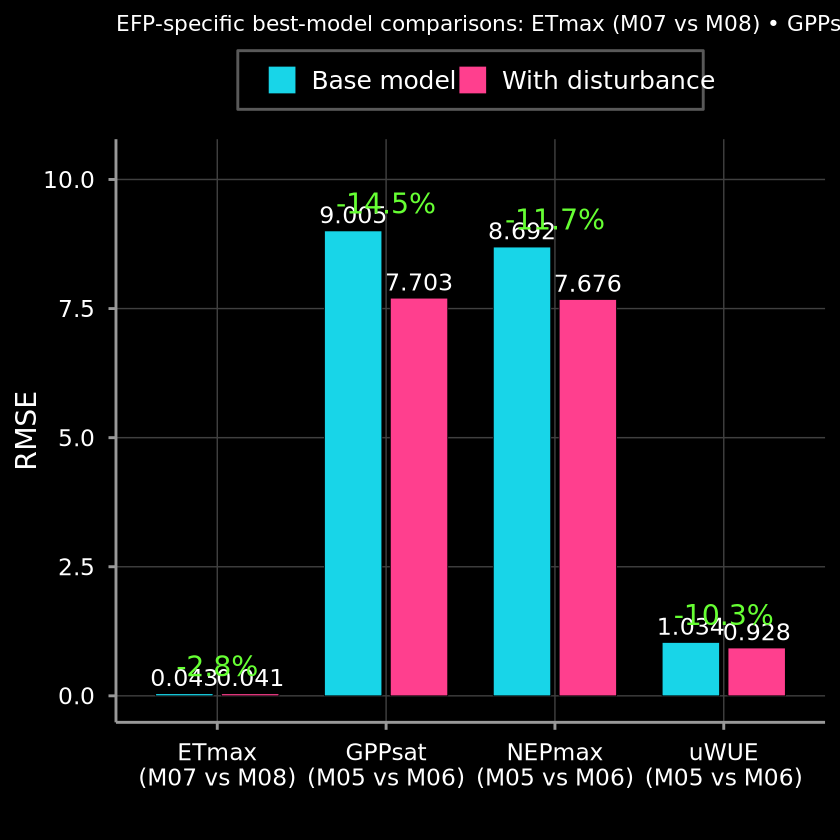

In [14]:
# =========================================================
# STEP 3b: RMSE bar plot — EFP-specific model comparisons
#  for 83 sites
# ETmax:  M07 (base) vs M08
# GPPsat: M05 (base) vs M06
# NEPmax: M05 (base) vs M06
# uWUE:   M05 (base) vs M06
# Dark style + percent change labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance/EFP_batch_metrics.csv"
)

# =========================================================
# Define which model pair to use per EFP
# =========================================================
efp_model_pairs <- list(
  ETmax  = c("M07", "M08"),
  GPPsat = c("M05", "M06"),
  NEPmax = c("M05", "M06"),
  uWUE   = c("M05", "M06")
)

# =========================================================
# Filter: keep only the relevant model for each EFP
# =========================================================
rows_keep <- rbindlist(lapply(names(efp_model_pairs), function(efp) {
  pair <- efp_model_pairs[[efp]]
  base_pattern <- paste0("^", pair[1], "_", efp, "_")
  dist_pattern <- paste0("^", pair[2], "_", efp, "_")
  
  dt_base <- metrics[response == efp & grepl(base_pattern, model)]
  dt_dist <- metrics[response == efp & grepl(dist_pattern, model)]
  
  dt_base[, model_group := "Base model"]
  dt_dist[, model_group := "With disturbance"]
  
  rbind(dt_base, dt_dist)
}))

rows_keep[, model_group := factor(model_group,
                                   levels = c("Base model", "With disturbance"))]
rows_keep[, response := factor(response,
                                levels = c("ETmax", "GPPsat", "NEPmax", "uWUE"))]

# =========================================================
# Compute delta RMSE and percent change labels
# =========================================================
rmse_wide <- dcast(rows_keep, response ~ model_group, value.var = "RMSE")
rmse_wide[, delta_RMSE  := `With disturbance` - `Base model`]
rmse_wide[, pct_change  := 100 * delta_RMSE / `Base model`]
rmse_wide[, label       := paste0(ifelse(pct_change <= 0, "", "+"),
                                   sprintf("%.1f", pct_change), "%")]

# Add subtitle per EFP showing which pair was compared
rmse_wide[, pair_label := fifelse(
  response == "ETmax",
  "M07 vs M08",
  "M05 vs M06"
)]

label_dt <- merge(
  rmse_wide[, .(response, delta_RMSE, pct_change, label, pair_label)],
  rows_keep[, .(ymax = max(RMSE, na.rm = TRUE)), by = response],
  by = "response"
)
label_dt[, y_pos := ymax + 0.06 * max(rows_keep$RMSE, na.rm = TRUE)]

# =========================================================
# Plot
# =========================================================
bar_cols <- c(
  "Base model"       = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

# Build x-axis labels that include pair info
x_labels <- c(
  ETmax  = "ETmax\n(M07 vs M08)",
  GPPsat = "GPPsat\n(M05 vs M06)",
  NEPmax = "NEPmax\n(M05 vs M06)",
  uWUE   = "uWUE\n(M05 vs M06)"
)

p_rmse_dark <- ggplot(rows_keep,
                      aes(x = response, y = RMSE, fill = model_group)) +
  geom_col(
    position  = position_dodge(width = 0.78),
    width     = 0.68,
    color     = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", RMSE)),
    position = position_dodge(width = 0.78),
    vjust    = -0.45,
    size     = 5,
    color    = "white"
  ) +
  geom_text(
    data      = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size      = 6,
    color     = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  scale_x_discrete(labels = x_labels) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) +
               0.08 * max(rows_keep$RMSE, na.rm = TRUE))
  ) +
  labs(
    subtitle = paste(
      "EFP-specific best-model comparisons:",
      "ETmax (M07 vs M08) \u2022 GPPsat / NEPmax / uWUE (M05 vs M06)"
    ),
    x    = "",
    y    = "RMSE",
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background   = element_rect(fill = "black", color = NA),
    panel.background  = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key        = element_rect(fill = "black", color = NA),
    panel.grid.major  = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor  = element_blank(),
    axis.line         = element_line(color = "grey60"),
    axis.ticks        = element_line(color = "grey60"),
    plot.subtitle     = element_text(size = 13, color = "white"),
    axis.text         = element_text(size = 14, color = "white"),
    axis.title        = element_text(size = 17, color = "white"),
    legend.text       = element_text(size = 15, color = "white"),
    legend.position   = "top"
  )

print(p_rmse_dark)

ggsave(
  file.path(out_dir, "plot_RMSE_bestpairs_per_EFP_dark.pdf"),
  p_rmse_dark, width = 10, height = 6, bg = "black",
  device = cairo_pdf
)

ggsave(
  file.path(out_dir, "plot_RMSE_bestpairs_per_EFP_dark.png"),
  p_rmse_dark, width = 10, height = 6, dpi = 300, bg = "black"
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <a2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'EFP-specific best-model comparisons: ETmax (M07 vs M08) • GPPsat / NEPmax / uWUE (M05 vs M06)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in gr

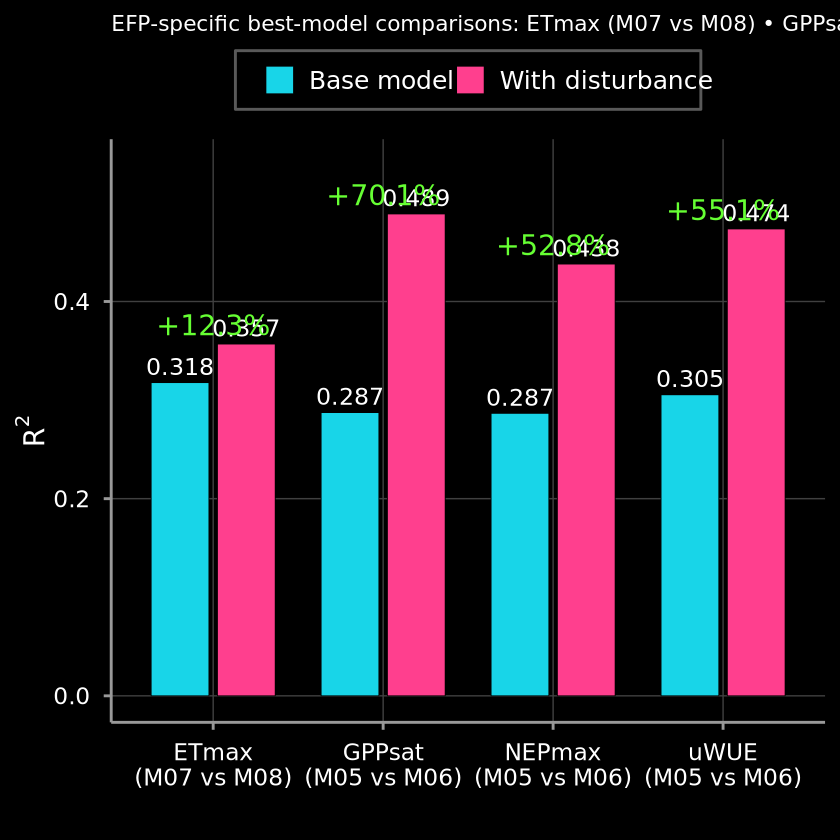

In [15]:
# =========================================================
# STEP 3c: R² bar plot — EFP-specific model comparisons
# for 83 sites
# ETmax:  M07 (base) vs M08
# GPPsat: M05 (base) vs M06
# NEPmax: M05 (base) vs M06
# uWUE:   M05 (base) vs M06
# Dark style + percent change labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance/EFP_batch_metrics.csv"
)

# =========================================================
# Define which model pair to use per EFP
# =========================================================
efp_model_pairs <- list(
  ETmax  = c("M07", "M08"),
  GPPsat = c("M05", "M06"),
  NEPmax = c("M05", "M06"),
  uWUE   = c("M05", "M06")
)

# =========================================================
# Filter: keep only the relevant model for each EFP
# =========================================================
rows_keep <- rbindlist(lapply(names(efp_model_pairs), function(efp) {
  pair <- efp_model_pairs[[efp]]
  base_pattern <- paste0("^", pair[1], "_", efp, "_")
  dist_pattern <- paste0("^", pair[2], "_", efp, "_")

  dt_base <- metrics[response == efp & grepl(base_pattern, model)]
  dt_dist <- metrics[response == efp & grepl(dist_pattern, model)]

  dt_base[, model_group := "Base model"]
  dt_dist[, model_group := "With disturbance"]

  rbind(dt_base, dt_dist)
}))

rows_keep[, model_group := factor(model_group,
                                   levels = c("Base model", "With disturbance"))]
rows_keep[, response := factor(response,
                                levels = c("ETmax", "GPPsat", "NEPmax", "uWUE"))]

# =========================================================
# Compute delta R² and percent change labels
# NOTE: for R², higher is better, so positive delta = improvement
# =========================================================
r2_wide <- dcast(rows_keep, response ~ model_group, value.var = "R2")
r2_wide[, delta_R2   := `With disturbance` - `Base model`]
r2_wide[, pct_change := 100 * delta_R2 / `Base model`]
r2_wide[, label      := paste0(
  ifelse(pct_change >= 0, "+", ""),
  sprintf("%.1f", pct_change), "%"
)]

r2_wide[, pair_label := fifelse(
  response == "ETmax",
  "M07 vs M08",
  "M05 vs M06"
)]

label_dt <- merge(
  r2_wide[, .(response, delta_R2, pct_change, label, pair_label)],
  rows_keep[, .(ymax = max(R2, na.rm = TRUE)), by = response],
  by = "response"
)
label_dt[, y_pos := ymax + 0.04 * max(rows_keep$R2, na.rm = TRUE)]

# =========================================================
# Plot
# =========================================================
bar_cols <- c(
  "Base model"       = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

x_labels <- c(
  ETmax  = "ETmax\n(M07 vs M08)",
  GPPsat = "GPPsat\n(M05 vs M06)",
  NEPmax = "NEPmax\n(M05 vs M06)",
  uWUE   = "uWUE\n(M05 vs M06)"
)

p_r2_dark <- ggplot(rows_keep,
                    aes(x = response, y = R2, fill = model_group)) +
  geom_col(
    position  = position_dodge(width = 0.78),
    width     = 0.68,
    color     = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", R2)),
    position = position_dodge(width = 0.78),
    vjust    = -0.45,
    size     = 5,
    color    = "white"
  ) +
  geom_text(
    data        = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size        = 6,
    # green = improvement (positive delta), red = degradation
    color       = ifelse(label_dt$pct_change >= 0, "#66FF33", "#FF4444")
  ) +
  scale_fill_manual(values = bar_cols) +
  scale_x_discrete(labels = x_labels) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) +
               0.06 * max(rows_keep$R2, na.rm = TRUE))
  ) +
  labs(
    subtitle = paste(
      "EFP-specific best-model comparisons:",
      "ETmax (M07 vs M08) \u2022 GPPsat / NEPmax / uWUE (M05 vs M06)"
    ),
    x    = "",
    y    = expression(R^2),
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background   = element_rect(fill = "black", color = NA),
    panel.background  = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key        = element_rect(fill = "black", color = NA),
    panel.grid.major  = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor  = element_blank(),
    axis.line         = element_line(color = "grey60"),
    axis.ticks        = element_line(color = "grey60"),
    plot.subtitle     = element_text(size = 13, color = "white"),
    axis.text         = element_text(size = 14, color = "white"),
    axis.title        = element_text(size = 17, color = "white"),
    legend.text       = element_text(size = 15, color = "white"),
    legend.position   = "top"
  )

print(p_r2_dark)

ggsave(
  file.path(out_dir, "plot_R2_bestpairs_per_EFP_dark.pdf"),
  p_r2_dark, width = 10, height = 6, bg = "black",
  device = cairo_pdf
)

ggsave(
  file.path(out_dir, "plot_R2_bestpairs_per_EFP_dark.png"),
  p_r2_dark, width = 10, height = 6, dpi = 300, bg = "black"
)

Disturbance classes:
   disturbance_class     N
              <char> <int>
1:         Low (< 2)    68
2:        High (≥ 2)    15
Score range: 0 1 

Number of sites in final plot data:
   response n_sites
     <fctr>   <int>
1:    ETmax      13
2:   GPPsat      14
3:   NEPmax      14
4:     uWUE      14


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Sites (ranked low → high ΔRMSE)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Sites (ranked low → high ΔRMSE)' in 'mbcsToSbcs': dot substituted for <86>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Sites (ranked low → high ΔRMSE)' in 'mbcsToSbcs': dot substituted for <92>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Sites (ranked low → high ΔRMSE)' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Sites (ranked low → high ΔRMSE)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font me

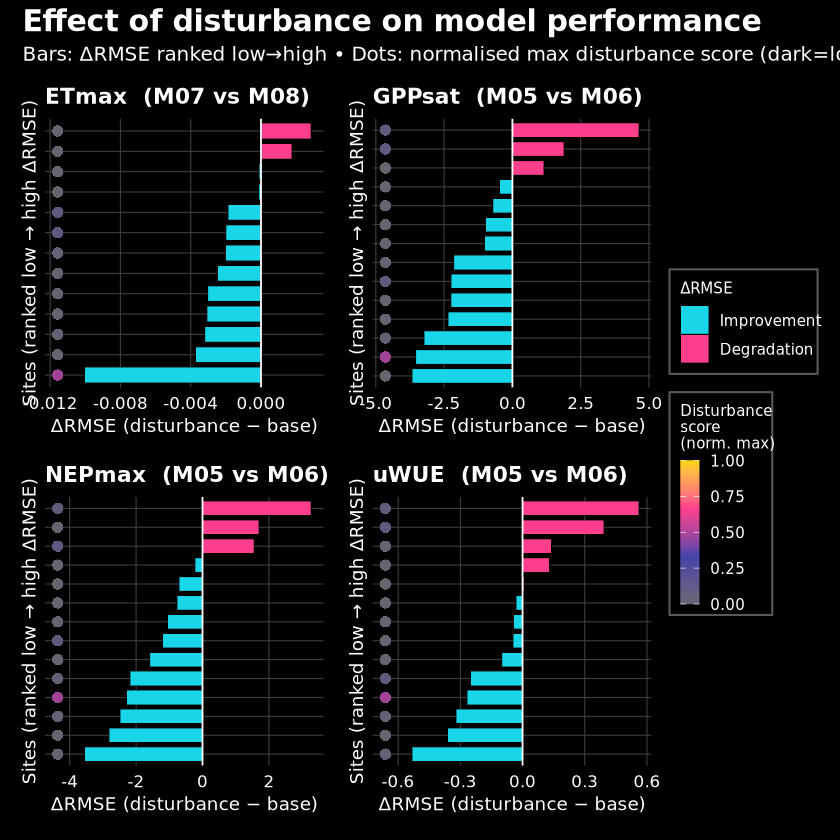

In [23]:
# =========================================================
# Site-level ΔRMSE plot — EFP-specific model comparisons
# Dots colored by continuous max_disturbance score
# Bars ranked low to high ΔRMSE within each facet
# Updated for: site_mean_disturbance_83sites.csv
# =========================================================

library(data.table)
library(ggplot2)
library(patchwork)

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

pred_file     <- file.path(out_dir, "EFP_batch_predictions.csv")
highdist_file <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance/site_mean_disturbance_83sites.csv"

pred     <- fread(pred_file)
highdist <- fread(highdist_file)

# =========================================================
# Prepare disturbance table
# New cols: mean_disturbance, max_disturbance, disturbance_class
# Normalise max_disturbance to [0,1] for the colour scale
# =========================================================
highdist[, score     := (max_disturbance - min(max_disturbance)) /
                        (max(max_disturbance) - min(max_disturbance) + 1e-9)]
highdist[, high_dist := disturbance_class != "Low (< 2)"]

cat("Disturbance classes:\n")
print(highdist[, .N, by = disturbance_class])
cat("Score range:", range(highdist$score), "\n")

response_vars <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

# =========================================================
# EFP-specific model pairs
# =========================================================
efp_model_pairs <- list(
  ETmax  = c("M07", "M08"),
  GPPsat = c("M05", "M06"),
  NEPmax = c("M05", "M06"),
  uWUE   = c("M05", "M06")
)

# =========================================================
# Compute site-level ΔRMSE for each EFP-specific pair
# =========================================================
site_delta <- rbindlist(lapply(names(efp_model_pairs), function(efp) {

  pair         <- efp_model_pairs[[efp]]
  base_pattern <- paste0("^", pair[1], "_", efp, "_")
  dist_pattern <- paste0("^", pair[2], "_", efp, "_")

  dt <- pred[response == efp &
               (grepl(base_pattern, model) | grepl(dist_pattern, model))]

  dt[, model_group := fifelse(grepl(base_pattern, model),
                               "Base model", "With disturbance")]

  site_rmse <- dt[
    !is.na(observed) & !is.na(predicted),
    .(RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))),
    by = .(response, SITE_ID, model_group)
  ]

  wide <- dcast(site_rmse, response + SITE_ID ~ model_group, value.var = "RMSE")
  wide[, delta_RMSE := `With disturbance` - `Base model`]
  wide[, pair_used  := paste(pair, collapse = " vs ")]
  wide
}))

# =========================================================
# Merge disturbance info — keep ALL prediction sites
# =========================================================

# all sites that exist in the RF predictions
all_pred_sites <- unique(site_delta[, .(SITE_ID)])

# make sure every predicted site has a disturbance row
highdist_all <- merge(
  all_pred_sites,
  highdist[, .(
    SITE_ID,
    mean_disturbance,
    max_disturbance,
    score,
    high_dist,
    disturbance_class
  )],
  by = "SITE_ID",
  all.x = TRUE
)

# fill missing disturbance info as low/zero
highdist_all[is.na(mean_disturbance),  mean_disturbance := 0]
highdist_all[is.na(max_disturbance),   max_disturbance := 0]
highdist_all[is.na(score),             score := 0]
highdist_all[is.na(high_dist),         high_dist := FALSE]
highdist_all[is.na(disturbance_class), disturbance_class := "Low (< 2)"]

# merge back to site-level delta RMSE
site_delta <- merge(
  site_delta,
  highdist_all,
  by = "SITE_ID",
  all.x = TRUE
)

site_delta[, response := factor(response, levels = response_vars)]

cat("\nNumber of sites in final plot data:\n")
print(site_delta[, .(n_sites = uniqueN(SITE_ID)), by = response])

# =========================================================
# Per-facet rank: low ΔRMSE at bottom, high at top
# =========================================================
site_delta[, y_rank := frank(delta_RMSE, ties.method = "first"), by = response]

# =========================================================
# Colors
# =========================================================
BAR_NEG   <- "#18D5E8"   # improvement (delta < 0)
BAR_POS   <- "#FF3F8E"   # degradation (delta > 0)
BG        <- "black"
FG        <- "white"
GRID      <- "grey25"
score_pal <- c("#696976", "#4444aa", "#FF3F8E", "#FFD700")

# =========================================================
# Panel builder
# =========================================================
make_panel <- function(efp) {

  dt <- site_delta[response == efp]
  setorder(dt, y_rank)
  dt[, site_f := factor(y_rank, levels = sort(unique(y_rank)))]

  dt[, bar_fill := fifelse(delta_RMSE < 0, "Improvement", "Degradation")]
  dt[, bar_fill := factor(bar_fill, levels = c("Improvement", "Degradation"))]

  bar_cols <- c("Improvement" = BAR_NEG, "Degradation" = BAR_POS)

  # Dot x position: just left of the leftmost bar
  x_min <- min(dt$delta_RMSE, na.rm = TRUE)
  x_max <- max(dt$delta_RMSE, na.rm = TRUE)
  x_rng <- x_max - x_min
  dot_x <- x_min - x_rng * 0.12

  # Pair label for title
  pair_lbl <- unique(dt$pair_used)

  ggplot(dt) +
    geom_col(
      aes(x = delta_RMSE, y = site_f, fill = bar_fill),
      width     = 0.75,
      color     = "black",
      linewidth = 0.12
    ) +
    geom_vline(xintercept = 0, color = FG, linewidth = 0.5) +
    # Dot = normalised max_disturbance score
    geom_point(
      aes(x = dot_x, y = site_f, color = score, size = score),
      size = 2.8,
      shape = 16,
      alpha = 0.95
      ) +
    scale_fill_manual(
      values = bar_cols,
      name   = expression(Delta*"RMSE"),
      guide  = guide_legend(order = 1)
    ) +
    scale_color_gradientn(
      colors = score_pal,
      limits = c(0, 1),
      name   = "Disturbance\nscore\n(norm. max)",
      guide  = guide_colorbar(order = 2, barheight = 6, barwidth = 0.8)
    ) +
  scale_size_continuous(
    range = c(1.5, 5),   # min → max dot size (tune if needed)
    name  = "Disturbance\nscore",
    guide = guide_legend(order = 3)
    ) +

    scale_y_discrete(labels = NULL) +
    labs(
      title = paste0(efp, "  (", pair_lbl, ")"),
      x     = expression(Delta*"RMSE (disturbance \u2212 base)"),
      y     = "Sites (ranked low \u2192 high \u0394RMSE)"
    ) +
    theme_minimal(base_size = 13) +
    theme(
      plot.background   = element_rect(fill = BG,       color = NA),
      panel.background  = element_rect(fill = BG,       color = NA),
      panel.grid.major  = element_line(color = GRID,    linewidth = 0.3),
      panel.grid.minor  = element_blank(),
      axis.text.x       = element_text(color = FG,   size = 10),
      axis.text.y       = element_blank(),
      axis.ticks.y      = element_blank(),
      axis.title        = element_text(color = FG,   size = 11),
      plot.title        = element_text(color = FG,   size = 13, face = "bold"),
      legend.background = element_rect(fill = "black", color = "grey35"),
      legend.key        = element_rect(fill = "black", color = NA),
      legend.text       = element_text(color = FG,   size = 9),
      legend.title      = element_text(color = FG,   size = 9),
      legend.position   = "right",
      plot.margin       = ggplot2::margin(8, 8, 8, 8)
    )
}

p_ETmax  <- make_panel("ETmax")
p_GPPsat <- make_panel("GPPsat")
p_NEPmax <- make_panel("NEPmax")
p_uWUE   <- make_panel("uWUE")

# =========================================================
# Combine
# =========================================================
final_plot <- (p_ETmax | p_GPPsat) / (p_NEPmax | p_uWUE) +
  plot_annotation(
    title    = "Effect of disturbance on model performance",
    subtitle = paste(
      "Bars: \u0394RMSE ranked low\u2192high \u2022",
      "Dots: normalised max disturbance score (dark=low, gold=high)"
    ),
    theme = theme(
      plot.background = element_rect(fill = BG, color = NA),
      plot.title      = element_text(color = FG, size = 18, face = "bold"),
      plot.subtitle   = element_text(color = FG, size = 12)
    )
  ) +
  plot_layout(guides = "collect") &
  theme(legend.position = "right")

print(final_plot)

ggsave(
  file.path(out_dir, "plot_deltaRMSE_dotScore_ranked_dark.pdf"),
  final_plot, width = 14, height = 12, bg = BG, device = cairo_pdf
)
ggsave(
  file.path(out_dir, "plot_deltaRMSE_dotScore_ranked_dark.png"),
  final_plot, width = 14, height = 12, dpi = 300, bg = BG
)

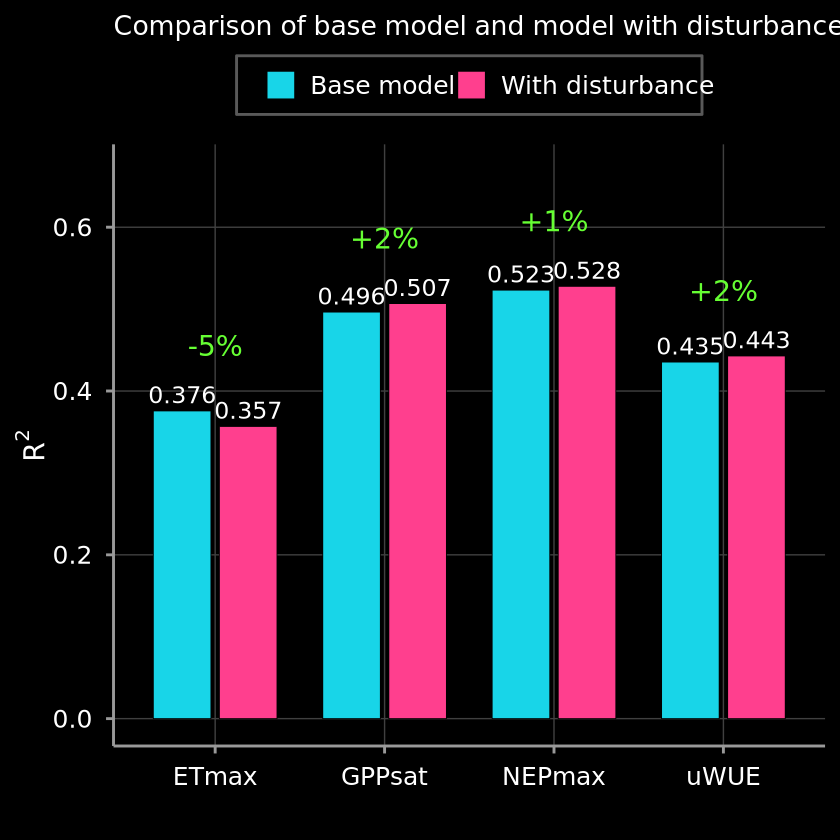

In [10]:
# =========================================================
# STEP 3: R2 bar plot for M02 vs M04 only
# Dark style + color code + percent improvement labels
# =========================================================

library(data.table)
library(ggplot2)

out_dir <- "derived_tables/final_results_3yr_deadwoodLag12_500m"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

metrics <- fread(
  "derived_tables/final_results_3yr_deadwoodLag12_500m/EFP_batch_metrics_ALL_3yr_lag24_anomlag12_deadwoodLag12Forest.csv"
)

efp_keep <- c("ETmax", "GPPsat", "NEPmax", "uWUE")

metrics_m2m4 <- metrics[
  response %in% efp_keep &
    (grepl("^M03_", model) | grepl("^M04_", model))
]

metrics_m2m4[, model_group := fifelse(
  grepl("^M03_", model),
  "Base model",
  "With disturbance"
)]

metrics_m2m4[, model_group := factor(
  model_group,
  levels = c("Base model", "With disturbance")
)]

metrics_m2m4[, response := factor(
  response,
  levels = c("ETmax", "GPPsat", "NEPmax", "uWUE")
)]

bar_cols <- c(
  "Base model" = "#18D5E8",
  "With disturbance" = "#FF3F8E"
)

r2_wide <- dcast(
  metrics_m2m4,
  response ~ model_group,
  value.var = "R2"
)

r2_wide[, delta_R2 := `With disturbance` - `Base model`]

r2_wide[, pct_improvement := 100 * delta_R2 / `Base model`]

r2_wide[, label := paste0(
  ifelse(pct_improvement >= 0, "+", ""),
  sprintf("%.0f", pct_improvement),
  "%"
)]

label_dt <- merge(
  r2_wide[, .(response, delta_R2, pct_improvement, label)],
  metrics_m2m4[, .(ymax = max(R2, na.rm = TRUE)), by = response],
  by = "response"
)

label_dt[, y_pos := ymax + 0.08]

p_r2_dark <- ggplot(metrics_m2m4, aes(x = response, y = R2, fill = model_group)) +
  geom_col(
    position = position_dodge(width = 0.78),
    width = 0.68,
    color = "black",
    linewidth = 0.25
  ) +
  geom_text(
    aes(label = sprintf("%.3f", R2)),
    position = position_dodge(width = 0.78),
    vjust = -0.45,
    size = 5,
    color = "white"
  ) +
  geom_text(
    data = label_dt,
    aes(x = response, y = y_pos, label = label),
    inherit.aes = FALSE,
    size = 6,
    #fontface = "bold",
    color = "#66FF33"
  ) +
  scale_fill_manual(values = bar_cols) +
  coord_cartesian(
    ylim = c(0, max(label_dt$y_pos, na.rm = TRUE) + 0.06)
  ) +
  labs(
    #title = "Does deadwood improve model performance?",
    subtitle = "Comparison of base model and model with disturbance",
    x = "",
    y = expression(R^2),
    fill = ""
  ) +
  theme_minimal(base_size = 18) +
  theme(
    plot.background = element_rect(fill = "black", color = NA),
    panel.background = element_rect(fill = "black", color = NA),
    legend.background = element_rect(fill = "black", color = "grey35"),
    legend.key = element_rect(fill = "black", color = NA),
    panel.grid.major = element_line(color = "grey25", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    plot.title = element_text(size = 24, face = "bold", color = "white"),
    plot.subtitle = element_text(size = 16, color = "white"),
    axis.text = element_text(size = 15, color = "white"),
    axis.title = element_text(size = 17, color = "white"),
    legend.text = element_text(size = 15, color = "white"),
    legend.position = "top"
  )


print(p_r2_dark)

ggsave(
  file.path(out_dir, "plot_R2_M03_vs_M04_deadwood_dark_Fcover.pdf"),
  p_r2_dark,
  width = 10,
  height = 6,
  bg = "black"
)

ggsave(
  file.path(out_dir, "plot_R2_M03_vs_M04_deadwood_dark_Fcover.png"),
  p_r2_dark,
  width = 10,
  height = 6,
  dpi = 300,
  bg = "black"
)